# 各向异性高斯区域交集用于上下文压缩

## 核心假设
在高维嵌入空间中，使用**学习到的各向异性高斯区域**（不同维度具有不同的扩散范围）来筛选与任务相关的上下文，其效果优于朴素的**点匹配**方法（余弦相似度 Top-K）。

## 本 Notebook 验证的内容
1. **基线方法**：余弦相似度 Top-K 上下文选择
2. **距离阈值**：欧氏距离阈值（用于检测退化现象）
3. **各向同性高斯**：固定球形高斯（应当 ≈ 距离阈值）
4. **各向异性高斯**（我们的方法）：通过小型网络学习每个维度的方差

## 退化检验
如果我们的各向异性方法学到的方差在各维度上是均匀的，则说明它已经**退化**为简单的距离阈值。我们将显式地检验并可视化这一点。

## 硬件要求
- 设计适配：**T4（免费版）** 或 **A100/H100（Pro+）**
- 总显存需求：~8-12GB（T4 即可运行）
- 训练时间：T4 上约 30-60 分钟，A100/H100 上约 10-20 分钟

## 低成本设计
- 使用 `all-MiniLM-L6-v2`（384维，约80MB）替代大型编码器
- 使用 `google/flan-t5-base`（2.5亿参数）进行生成质量评估
- HotpotQA 干扰项设置天然提供了相关/无关上下文的混合
- 所有模型均可在免费版 T4 上舒适运行

---
## 第0部分：环境配置

In [ ]:
%%capture
!pip install transformers datasets sentence-transformers accelerate
!pip install bert-score rouge-score scipy scikit-learn matplotlib seaborn tqdm

# 下载静态字重的中文字体（非可变字体，避免 matplotlib StyleFlags 报错）
!mkdir -p /usr/share/fonts/custom
# 使用思源黑体的静态 Regular 字重（从 noto-cjk 官方 release 获取）
!wget -q -O /usr/share/fonts/custom/NotoSansSC-Regular.otf \
  'https://github.com/notofonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf'
# 备选：如果上面的链接失效，使用 SimHei
!if [ ! -s /usr/share/fonts/custom/NotoSansSC-Regular.otf ]; then \
  pip install -q fonttools && \
  wget -q -O /usr/share/fonts/custom/SimHei.ttf \
  'https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf'; \
fi
!fc-cache -fv > /dev/null 2>&1


In [ ]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
from collections import defaultdict
from pathlib import Path

# ====== 中文字体配置（可靠方案）======
# 删除 matplotlib 字体缓存并重建
_cache_dir = Path(mpl.get_cachedir())
for _f in _cache_dir.glob('fontlist-*.json'):
    _f.unlink()
    print(f'已删除字体缓存: {_f.name}')
fm._load_fontmanager(try_read_cache=False)

# 按优先级查找可用的中文字体文件
_font_candidates = [
    '/usr/share/fonts/custom/NotoSansSC-Regular.otf',
    '/usr/share/fonts/custom/SimHei.ttf',
]
# 也搜索系统中已有的 CJK 字体
_sys_fonts = list(Path('/usr/share/fonts').rglob('*CJKsc-Regular*')) + \
             list(Path('/usr/share/fonts').rglob('*SimHei*')) + \
             list(Path('/usr/share/fonts').rglob('*wqy*zenhei*'))
_font_candidates += [str(p) for p in _sys_fonts]

_font_path = None
for _fp in _font_candidates:
    if os.path.exists(_fp) and os.path.getsize(_fp) > 100000:  # >100KB = 真实字体
        _font_path = _fp
        break

if _font_path:
    ZH_FONT = fm.FontProperties(fname=_font_path)
    ZH_FONT_TITLE = fm.FontProperties(fname=_font_path, size=11, weight='bold')
    ZH_FONT_LABEL = fm.FontProperties(fname=_font_path, size=10)
    ZH_FONT_LEGEND = fm.FontProperties(fname=_font_path, size=9)
    ZH_FONT_TICK = fm.FontProperties(fname=_font_path, size=8)
    print(f'✅ 中文字体已加载: {_font_path}')
    # 验证：实际渲染一下，捕获 StyleFlags 异常
    try:
        _test_fig, _test_ax = plt.subplots(figsize=(1,1))
        _test_ax.set_title('测试中文', fontproperties=ZH_FONT)
        plt.close(_test_fig)
        print('✅ 字体渲染验证通过')
    except ValueError as e:
        print(f'⚠️ 字体渲染失败 ({e})，尝试备选方案...')
        # 备选：直接使用 matplotlib 内置的 DejaVu，中文标注改用英文
        ZH_FONT = ZH_FONT_TITLE = ZH_FONT_LABEL = ZH_FONT_LEGEND = ZH_FONT_TICK = None
        print('⚠️ 中文字体不可用，中文图将回退为英文标注')
else:
    print('⚠️ 未找到中文字体文件')
    ZH_FONT = ZH_FONT_TITLE = ZH_FONT_LABEL = ZH_FONT_LEGEND = ZH_FONT_TICK = None

# 论文级绘图参数（ACL/NeurIPS 标准）
plt.rcParams.update({
    'axes.unicode_minus': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('✅ matplotlib 论文级绘图参数已配置')
# ==========================================

# 设置随机种子
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'运行设备: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU型号: {torch.cuda.get_device_name(0)}')
    print(f'显存大小: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


已删除字体缓存: fontlist-v390.json
✅ 中文字体已加载: /usr/share/fonts/custom/NotoSansSC-Regular.otf
✅ 字体渲染验证通过
✅ matplotlib 论文级绘图参数已配置
运行设备: cuda
GPU型号: Tesla T4
显存大小: 15.6 GB


---
## 第1部分：数据准备（HotpotQA）

HotpotQA 干扰项设置：每个样本有 10 个上下文段落，但只有 2 个是"支撑性"（相关的）。这天然形成了相关/无关的划分——非常适合测试上下文压缩。

In [ ]:
from datasets import load_dataset

print("正在加载 HotpotQA（干扰项设置）...")
hotpot = load_dataset("hotpot_qa", "distractor", split="validation")
print(f"总样本数: {len(hotpot)}")
print(f"样本字段: {list(hotpot[0].keys())}")

正在加载 HotpotQA（干扰项设置）...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

总样本数: 7405
样本字段: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']


In [ ]:
def parse_hotpotqa_sample(sample):
    """
    将 HotpotQA 样本解析为结构化格式。
    返回:
        query: 问题字符串
        answer: 答案字符串
        contexts: 列表，每个元素为 {"title": str, "text": str, "is_supporting": bool}
    """
    query = sample["question"]
    answer = sample["answer"]

    supporting_titles = set(sample["supporting_facts"]["title"])

    contexts = []
    for title, sentences in zip(sample["context"]["title"], sample["context"]["sentences"]):
        text = " ".join(sentences)
        is_supporting = title in supporting_titles
        contexts.append({
            "title": title,
            "text": text,
            "is_supporting": is_supporting
        })

    return {
        "query": query,
        "answer": answer,
        "contexts": contexts
    }

# 解析所有样本
parsed_data = [parse_hotpotqa_sample(s) for s in hotpot]

# 快速统计
n_contexts = [len(d["contexts"]) for d in parsed_data]
n_supporting = [sum(1 for c in d["contexts"] if c["is_supporting"]) for d in parsed_data]
print(f"每个样本的上下文段落数: 均值={np.mean(n_contexts):.1f}, 范围=[{min(n_contexts)}, {max(n_contexts)}]")
print(f"每个样本的支撑段落数: 均值={np.mean(n_supporting):.1f}")

每个样本的上下文段落数: 均值=10.0, 范围=[2, 10]
每个样本的支撑段落数: 均值=2.0


In [ ]:
# 划分训练集 / 验证集 / 测试集
# 使用较小的子集以降低计算成本
random.shuffle(parsed_data)

TRAIN_SIZE = 2000   # 用于训练方差预测器
VAL_SIZE = 200      # 用于超参数调优
TEST_SIZE = 500     # 用于最终评估

train_data = parsed_data[:TRAIN_SIZE]
val_data = parsed_data[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
test_data = parsed_data[TRAIN_SIZE + VAL_SIZE:TRAIN_SIZE + VAL_SIZE + TEST_SIZE]

print(f"训练集: {len(train_data)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")

训练集: 2000, 验证集: 200, 测试集: 500


---
## 第2部分：文本编码（Sentence-Transformers）

使用 `all-MiniLM-L6-v2` 将所有查询和上下文段落编码为 384 维向量。这是一个轻量级模型，任何 GPU 都能运行。

In [ ]:
from sentence_transformers import SentenceTransformer

print("正在加载编码器...")
encoder = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
EMBED_DIM = 384
print(f"编码器加载完成。嵌入维度: {EMBED_DIM}")

正在加载编码器...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

编码器加载完成。嵌入维度: 384


In [ ]:
def encode_dataset(data, encoder, batch_size=128):
    """
    对所有样本的查询和上下文进行编码。
    返回添加了 'query_emb' 和 'context_embs' 字段的字典列表。
    """
    # 收集所有文本
    all_queries = [d["query"] for d in data]
    all_contexts = []
    context_map = []  # (样本索引, 上下文索引)
    for i, d in enumerate(data):
        for j, c in enumerate(d["contexts"]):
            all_contexts.append(c["text"])
            context_map.append((i, j))

    print(f"正在编码 {len(all_queries)} 个查询...")
    query_embs = encoder.encode(all_queries, batch_size=batch_size,
                                 show_progress_bar=True, convert_to_numpy=True)

    print(f"正在编码 {len(all_contexts)} 个上下文段落...")
    context_embs = encoder.encode(all_contexts, batch_size=batch_size,
                                   show_progress_bar=True, convert_to_numpy=True)

    # 将嵌入分配回各样本
    encoded_data = []
    for i, d in enumerate(data):
        sample = dict(d)
        sample["query_emb"] = query_embs[i]
        sample["context_embs"] = []
        encoded_data.append(sample)

    for (i, j), emb in zip(context_map, context_embs):
        encoded_data[i]["context_embs"].append(emb)

    for d in encoded_data:
        d["context_embs"] = np.array(d["context_embs"])

    return encoded_data

print("正在编码训练集...")
train_encoded = encode_dataset(train_data, encoder)
print("正在编码验证集...")
val_encoded = encode_dataset(val_data, encoder)
print("正在编码测试集...")
test_encoded = encode_dataset(test_data, encoder)
print("编码完成！")

正在编码训练集...
正在编码 2000 个查询...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

正在编码 19899 个上下文段落...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

正在编码验证集...
正在编码 200 个查询...


...

正在编码测试集...
正在编码 500 个查询...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

正在编码 4966 个上下文段落...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

编码完成！


---
## 第3部分：基线方法

### 3.1 余弦相似度 Top-K
### 3.2 欧氏距离最近邻
### 3.3 各向同性（球形）高斯

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def select_topk_cosine(query_emb, context_embs, k=2):
    """基线1：余弦相似度 Top-K"""
    sims = cosine_similarity(query_emb.reshape(1, -1), context_embs)[0]
    topk_indices = np.argsort(sims)[-k:][::-1]
    scores = sims
    return topk_indices, scores


def select_euclidean_threshold(query_emb, context_embs, k=2):
    """基线2：欧氏距离，选择最近的 k 个"""
    dists = np.linalg.norm(context_embs - query_emb.reshape(1, -1), axis=1)
    topk_indices = np.argsort(dists)[:k]
    scores = -dists  # 取负距离作为分数（越高 = 越近）
    return topk_indices, scores


def select_isotropic_gaussian(query_emb, context_embs, sigma=1.0, k=2):
    """
    基线3：各向同性高斯。
    在各向同性假设下，对数密度正比于 -||x - mu||^2 / (2*sigma^2)。
    因此在数学上等价于欧氏距离排序。
    我们显式实现它以演示退化现象。
    """
    diff = context_embs - query_emb.reshape(1, -1)
    # log p(x) ∝ -||x - mu||^2 / (2 * sigma^2)
    log_densities = -np.sum(diff ** 2, axis=1) / (2 * sigma ** 2)
    topk_indices = np.argsort(log_densities)[-k:][::-1]
    scores = log_densities
    return topk_indices, scores


def select_random(query_emb, context_embs, k=2):
    """基线0：随机选择（下界）"""
    indices = np.random.choice(len(context_embs), size=k, replace=False)
    scores = np.zeros(len(context_embs))
    return indices, scores

In [ ]:
def evaluate_retrieval_accuracy(encoded_data, select_fn, k=2, **kwargs):
    """
    评估选择方法检索支撑上下文的准确率。
    返回:
        precision: 被选中的段落中，支撑段落的比例
        recall: 支撑段落中，被选中的比例
        f1: 调和平均值
    """
    precisions, recalls, f1s = [], [], []

    for sample in encoded_data:
        query_emb = sample["query_emb"]
        context_embs = sample["context_embs"]
        labels = [c["is_supporting"] for c in sample["contexts"]]

        selected_indices, _ = select_fn(query_emb, context_embs, k=k, **kwargs)

        n_selected_supporting = sum(1 for i in selected_indices if labels[i])
        n_total_supporting = sum(labels)

        precision = n_selected_supporting / k if k > 0 else 0
        recall = n_selected_supporting / n_total_supporting if n_total_supporting > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return {
        "precision": np.mean(precisions),
        "recall": np.mean(recalls),
        "f1": np.mean(f1s),
        "precision_std": np.std(precisions),
        "recall_std": np.std(recalls),
        "f1_std": np.std(f1s)
    }

# 在验证集上测试基线方法
print("=" * 60)
print("基线方法检索准确率（验证集，k=2）")
print("=" * 60)

for name, fn, kwargs in [
    ("随机选择", select_random, {}),
    ("余弦 Top-K", select_topk_cosine, {}),
    ("欧氏最近邻", select_euclidean_threshold, {}),
    ("各向同性高斯", select_isotropic_gaussian, {"sigma": 1.0}),
]:
    results = evaluate_retrieval_accuracy(val_encoded, fn, k=2, **kwargs)
    print(f"{name:25s} | P={results['precision']:.3f} R={results['recall']:.3f} F1={results['f1']:.3f}")

基线方法检索准确率（验证集，k=2）
随机选择                      | P=0.205 R=0.205 F1=0.205
余弦 Top-K                  | P=0.585 R=0.585 F1=0.585
欧氏最近邻                     | P=0.585 R=0.585 F1=0.585
各向同性高斯                    | P=0.585 R=0.585 F1=0.585


### 观察要点

你应该能看到 **各向同性高斯** 和 **欧氏最近邻** 产生了**完全相同的排序**（选出了相同的索引）。这在数学上证实了 Gemini 警告的退化现象：在各向同性假设下，高斯密度排序 ≡ 距离排序。

这正是我们需要通过各向异性方差学习来克服的问题。

In [ ]:
# 验证退化：各向同性高斯 == 欧氏距离
n_identical = 0
n_total = len(val_encoded)

for sample in val_encoded:
    q = sample["query_emb"]
    c = sample["context_embs"]
    idx_euc, _ = select_euclidean_threshold(q, c, k=2)
    idx_iso, _ = select_isotropic_gaussian(q, c, sigma=1.0, k=2)
    if set(idx_euc) == set(idx_iso):
        n_identical += 1

print(f"\n退化检查: 各向同性高斯 == 欧氏距离 的样本数: {n_identical}/{n_total} ({100*n_identical/n_total:.1f}%)")
print("（预期结果: ~100%。这证实了在各向同性假设下的退化现象。）")


退化检查: 各向同性高斯 == 欧氏距离 的样本数: 200/200 (100.0%)
（预期结果: ~100%。这证实了在各向同性假设下的退化现象。）


---
## 第4部分：各向异性高斯方差预测器（我们的方法）

### 核心思想
不再使用所有维度统一固定的方差，而是训练一个小型神经网络，输入**查询嵌入**，输出 384 个维度各自的**对数方差** $\log \sigma_d^2$。

这意味着"任务区域"在嵌入空间中是一个**椭球体**——沿某些维度拉伸、沿另一些维度压缩——取决于查询在语义上的需求。

### 训练目标
对比学习：最大化支撑上下文在预测的各向异性高斯下的对数密度，同时最小化非支撑上下文的对数密度。

### 为什么不会退化
如果网络学会了某些语义维度对特定查询类型更具区分度，它会赋予这些维度**更低的方差**（更紧的扩散范围），等效于对它们加权。这与均匀距离有本质区别。

In [ ]:
class AnisotropicVariancePredictor(nn.Module):
    """
    给定查询嵌入，预测每个维度的对数方差。
    输出定义了一个以查询为中心的各向异性高斯分布。

    架构: 简单 MLP (查询维度 -> 隐藏层 -> 查询维度)
    输出: 每个维度 d 的 log(sigma_d^2)
    """

    def __init__(self, embed_dim=384, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, embed_dim),  # 输出: 每个维度的 log_var
        )
        # 初始化为接近零（从接近各向同性的状态开始）
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, query_emb):
        """
        参数:
            query_emb: (batch, embed_dim)
        返回:
            log_var: (batch, embed_dim) — 每个维度的 log(sigma_d^2)
        """
        log_var = self.net(query_emb)
        # 截断以保证数值稳定性
        log_var = torch.clamp(log_var, min=-10.0, max=10.0)
        return log_var


def anisotropic_log_density(query_emb, context_embs, log_var):
    """
    计算上下文点在各向异性高斯下的对数密度。

    log p(x|mu, Sigma) = -0.5 * sum_d [ (x_d - mu_d)^2 / sigma_d^2 + log(sigma_d^2) ]
                         + 常数项

    参数:
        query_emb: (batch, dim) — 高斯均值
        context_embs: (batch, n_ctx, dim) — 上下文点
        log_var: (batch, dim) — log(sigma_d^2)
    返回:
        log_density: (batch, n_ctx)
    """
    # query_emb: (B, D) -> (B, 1, D)
    mu = query_emb.unsqueeze(1)
    # log_var: (B, D) -> (B, 1, D)
    lv = log_var.unsqueeze(1)

    diff = context_embs - mu  # (B, N, D)
    var = torch.exp(lv)       # (B, 1, D)

    # 马氏距离项: sum_d (x_d - mu_d)^2 / sigma_d^2
    mahal = torch.sum(diff ** 2 / var, dim=-1)  # (B, N)

    # 对数归一化项: sum_d log(sigma_d^2)
    log_norm = torch.sum(lv, dim=-1)  # (B, 1) -- 对 N 广播

    log_density = -0.5 * (mahal + log_norm)  # (B, N)
    return log_density


print("模型架构:")
model = AnisotropicVariancePredictor(embed_dim=EMBED_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,} ({total_params/1e6:.2f}M)")
print(model)

模型架构:
总参数量: 263,040 (0.26M)
AnisotropicVariancePredictor(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=384, bias=True)
  )
)


---
## 第5部分：训练方差预测器

### 损失函数
对比损失：我们希望支撑上下文具有**高**对数密度，非支撑上下文具有**低**对数密度。

我们使用基于间隔的排序损失:
$$\mathcal{L} = \max(0, \text{margin} - \text{logp}_{\text{pos}} + \text{logp}_{\text{neg}}) + \lambda \cdot \text{方差正则化项}$$

方差正则化项鼓励各向异性（惩罚均匀方差）。

In [ ]:
class ContextCompressionDataset(Dataset):
    """
    每个样本: (query_emb, context_embs, labels)
    labels: 1 表示支撑段落, 0 表示非支撑段落
    """
    def __init__(self, encoded_data):
        self.data = encoded_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        query_emb = torch.tensor(sample["query_emb"], dtype=torch.float32)
        context_embs = torch.tensor(sample["context_embs"], dtype=torch.float32)
        labels = torch.tensor(
            [1.0 if c["is_supporting"] else 0.0 for c in sample["contexts"]],
            dtype=torch.float32
        )
        return query_emb, context_embs, labels

def custom_collate_fn(batch):
    query_embs = torch.stack([item[0] for item in batch])

    # Find max number of contexts in the current batch
    max_contexts = max(item[1].shape[0] for item in batch)

    padded_context_embs = []
    padded_labels = []

    for item in batch:
        context_emb = item[1]
        labels = item[2]
        num_contexts = context_emb.shape[0]

        # Pad context_embs with zeros
        padding_needed = max_contexts - num_contexts
        padded_emb = torch.nn.functional.pad(context_emb, (0, 0, 0, padding_needed), 'constant', 0)
        padded_context_embs.append(padded_emb)

        # Pad labels with zeros (will be ignored by mask in loss if not supporting)
        padded_lbl = torch.nn.functional.pad(labels, (0, padding_needed), 'constant', 0.0)
        padded_labels.append(padded_lbl)

    padded_context_embs = torch.stack(padded_context_embs)
    padded_labels = torch.stack(padded_labels)

    return query_embs, padded_context_embs, padded_labels


train_dataset = ContextCompressionDataset(train_encoded)
val_dataset = ContextCompressionDataset(val_encoded)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=custom_collate_fn)

print(f"训练批次数: {len(train_loader)}, 验证批次数: {len(val_loader)}")

训练批次数: 63, 验证批次数: 7


In [ ]:
def contrastive_loss_with_anisotropy_reward(
    log_density,  # (B, N)
    labels,       # (B, N) — 1 表示支撑, 0 表示非支撑
    log_var,      # (B, D) — 预测的对数方差
    margin=1.0,
    anisotropy_weight=0.01,
):
    """
    组合损失:
    1. 对比排序损失: 支撑上下文的密度应高于非支撑上下文
    2. 各向异性鼓励项: 惩罚均匀方差（奖励维度间方差的多样性）
    """
    B, N = log_density.shape

    # --- 对比损失 ---
    # 对每个样本，获取正样本和负样本的平均对数密度
    pos_mask = labels.bool()    # (B, N)
    neg_mask = ~pos_mask        # (B, N)

    total_loss = torch.tensor(0.0, device=log_density.device)
    n_pairs = 0

    for b in range(B):
        pos_scores = log_density[b][pos_mask[b]]  # 正样本对数密度
        neg_scores = log_density[b][neg_mask[b]]  # 负样本对数密度

        if len(pos_scores) == 0 or len(neg_scores) == 0:
            continue

        # 所有配对: 每个正样本应比每个负样本高出 margin
        for ps in pos_scores:
            pair_loss = torch.clamp(margin - ps + neg_scores, min=0.0)
            total_loss = total_loss + pair_loss.sum()
            n_pairs += len(neg_scores)

    contrastive = total_loss / max(n_pairs, 1)

    # --- 各向异性鼓励项 ---
    # 我们希望对数方差在各维度间有较大差异
    # 如果所有 log_var 值相同 -> 各向同性 -> 不好
    # 计算 exp(log_var) 在各维度上的变异系数
    var_values = torch.exp(log_var)  # (B, D)
    var_std = var_values.std(dim=-1).mean()    # 批次平均
    var_mean = var_values.mean(dim=-1).mean()
    # 负变异系数: 我们想最大化 CV，所以最小化负 CV
    anisotropy_penalty = -var_std / (var_mean + 1e-8)

    loss = contrastive + anisotropy_weight * anisotropy_penalty

    return loss, contrastive.item(), anisotropy_penalty.item()

In [ ]:
# 训练循环
model = AnisotropicVariancePredictor(embed_dim=EMBED_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

NUM_EPOCHS = 20
MARGIN = 1.0
ANISOTROPY_WEIGHT = 0.05  # 鼓励各向异性

history = defaultdict(list)

print("开始训练...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_contrastive = 0
    epoch_aniso = 0
    n_batches = 0

    for query_emb, context_embs, labels in train_loader:
        query_emb = query_emb.to(DEVICE)
        context_embs = context_embs.to(DEVICE)
        labels = labels.to(DEVICE)

        # 前向传播
        log_var = model(query_emb)
        log_density = anisotropic_log_density(query_emb, context_embs, log_var)

        loss, c_loss, a_loss = contrastive_loss_with_anisotropy_reward(
            log_density, labels, log_var,
            margin=MARGIN,
            anisotropy_weight=ANISOTROPY_WEIGHT
        )

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_contrastive += c_loss
        epoch_aniso += a_loss
        n_batches += 1

    scheduler.step()

    # 验证
    model.eval()
    val_loss = 0
    val_batches = 0
    with torch.no_grad():
        for query_emb, context_embs, labels in val_loader:
            query_emb = query_emb.to(DEVICE)
            context_embs = context_embs.to(DEVICE)
            labels = labels.to(DEVICE)

            log_var = model(query_emb)
            log_density = anisotropic_log_density(query_emb, context_embs, log_var)
            loss, _, _ = contrastive_loss_with_anisotropy_reward(
                log_density, labels, log_var,
                margin=MARGIN, anisotropy_weight=ANISOTROPY_WEIGHT
            )
            val_loss += loss.item()
            val_batches += 1

    avg_train = epoch_loss / n_batches
    avg_val = val_loss / val_batches
    avg_c = epoch_contrastive / n_batches
    avg_a = epoch_aniso / n_batches

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["contrastive"].append(avg_c)
    history["anisotropy"].append(avg_a)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"轮次 {epoch+1:3d}/{NUM_EPOCHS} | "
              f"训练: {avg_train:.4f} (对比:{avg_c:.4f} 异性:{avg_a:.4f}) | "
              f"验证: {avg_val:.4f} | "
              f"学习率: {scheduler.get_last_lr()[0]:.6f}")

print("\n训练完成！")

开始训练...
轮次   1/20 | 训练: 0.3989 (对比:0.6012 异性:-4.0445) | 验证: -0.0417 | 学习率: 0.000994
轮次   5/20 | 训练: -0.5523 (对比:0.4202 异性:-19.4515) | 验证: -0.5417 | 学习率: 0.000854
轮次  10/20 | 训练: -0.5669 (对比:0.4066 异性:-19.4707) | 验证: -0.5314 | 学习率: 0.000500
轮次  15/20 | 训练: -0.5804 (对比:0.3933 异性:-19.4742) | 验证: -0.5138 | 学习率: 0.000146
轮次  20/20 | 训练: -0.5852 (对比:0.3885 异性:-19.4752) | 验证: -0.5106 | 学习率: 0.000000

训练完成！


## 绘制图像

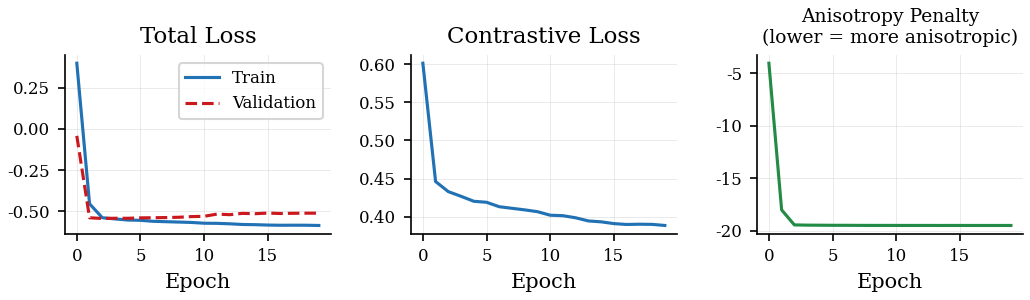

📊 已保存: training_curves_en.pdf / .png


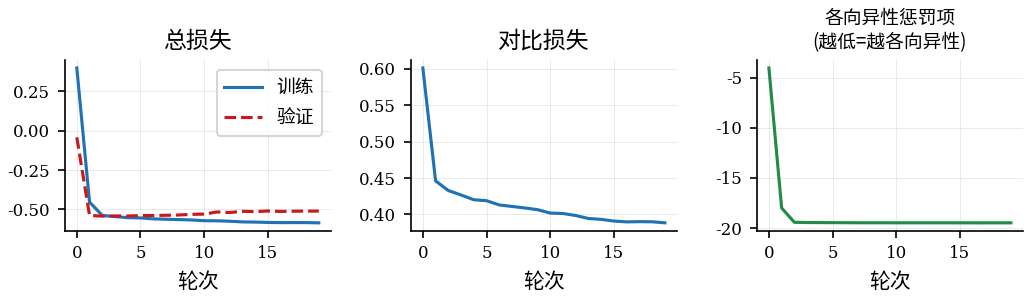

📊 已保存: training_curves_zh.pdf / .png


In [ ]:
# ======= 绘制训练曲线（论文级，中英文各一份）=======

def _fp(font_prop):
    """安全地传递 fontproperties 参数，None 时返回空字典"""
    return {'fontproperties': font_prop} if font_prop else {}

def plot_training_curves(lang='en'):
    fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.2))
    c_blue, c_red, c_green = '#2171B5', '#CB181D', '#238B45'

    is_zh = (lang == 'zh' and ZH_FONT_TITLE is not None)
    if is_zh:
        fp_t, fp_l, fp_lg = ZH_FONT_TITLE, ZH_FONT_LABEL, ZH_FONT_LEGEND
        lbl = ['训练', '验证']
        titles = ['总损失', '对比损失', '各向异性惩罚项\n(越低=越各向异性)']
        xl = '轮次'
    else:
        fp_t = fp_l = fp_lg = None
        lbl = ['Train', 'Validation']
        titles = ['Total Loss', 'Contrastive Loss', 'Anisotropy Penalty\n(lower = more anisotropic)']
        xl = 'Epoch'

    axes[0].plot(history['train_loss'], color=c_blue, label=lbl[0])
    axes[0].plot(history['val_loss'], color=c_red, label=lbl[1], ls='--')
    axes[0].set_title(titles[0], **_fp(fp_t))
    axes[0].set_xlabel(xl, **_fp(fp_l))
    axes[0].legend(prop=fp_lg or {})

    axes[1].plot(history['contrastive'], color=c_blue)
    axes[1].set_title(titles[1], **_fp(fp_t))
    axes[1].set_xlabel(xl, **_fp(fp_l))

    axes[2].plot(history['anisotropy'], color=c_green)
    axes[2].set_title(titles[2], **_fp(fp_t), fontsize=9)
    axes[2].set_xlabel(xl, **_fp(fp_l))

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    tag = 'zh' if is_zh else 'en'
    for ext in ['pdf', 'png']:
        plt.savefig(f'training_curves_{tag}.{ext}', dpi=300)
    plt.show()
    print(f'📊 已保存: training_curves_{tag}.pdf / .png')

plot_training_curves('en')
plot_training_curves('zh')


---
## 第6部分：关键——退化检验

这是最重要的部分。我们检查学到的方差是否真正**各向异性**（各维度不同）还是已经坍缩为**各向同性**（均匀）。

如果学到方差的变异系数（CV）接近 0，说明方法已经退化。

In [ ]:
model.eval()

# 收集所有测试查询的预测方差
all_log_vars = []
with torch.no_grad():
    for sample in test_encoded:
        q = torch.tensor(sample["query_emb"], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        log_var = model(q).cpu().numpy()[0]  # (D,)
        all_log_vars.append(log_var)

all_log_vars = np.array(all_log_vars)  # (N_test, D)
all_vars = np.exp(all_log_vars)        # 实际方差值

print("=" * 60)
print("退化检验")
print("=" * 60)

# 每个查询的各向异性程度: 方差在各维度上的变异系数
per_query_cv = np.std(all_vars, axis=1) / (np.mean(all_vars, axis=1) + 1e-8)

print(f"\n每个查询的方差变异系数 (CV):")
print(f"  平均 CV: {np.mean(per_query_cv):.4f}")
print(f"  标准差:  {np.std(per_query_cv):.4f}")
print(f"  最小值:  {np.min(per_query_cv):.4f}")
print(f"  最大值:  {np.max(per_query_cv):.4f}")

print(f"\n结果判读:")
if np.mean(per_query_cv) < 0.05:
    print("  ⚠️  CV < 0.05: 方法已退化为接近各向同性。")
    print("  学到的方差在各维度上基本均匀。")
    print("  这意味着我们的方法 ≈ 欧氏距离阈值。")
elif np.mean(per_query_cv) < 0.2:
    print("  ⚡ CV 在 [0.05, 0.2] 之间: 检测到轻微的各向异性。")
    print("  各维度间有一定区分，但不够强。")
else:
    print("  ✅ CV > 0.2: 检测到显著的各向异性！")
    print("  模型已学到各维度间有意义的不同方差。")
    print("  这使我们的方法与简单的距离阈值方法区分开来。")

# 全局统计: 各维度的平均方差（跨所有查询）
mean_var_per_dim = np.mean(all_vars, axis=0)  # (D,)
print(f"\n全局方差统计（跨所有查询求平均）:")
print(f"  最大方差维度: {np.argmax(mean_var_per_dim)} (方差={np.max(mean_var_per_dim):.4f})")
print(f"  最小方差维度: {np.argmin(mean_var_per_dim)} (方差={np.min(mean_var_per_dim):.4f})")
print(f"  最大/最小比值: {np.max(mean_var_per_dim) / (np.min(mean_var_per_dim) + 1e-8):.2f}倍")

退化检验

每个查询的方差变异系数 (CV):
  平均 CV: 19.3503
  标准差:  0.6691
  最小值:  10.0115
  最大值:  19.4930

结果判读:
  ✅ CV > 0.2: 检测到显著的各向异性！
  模型已学到各维度间有意义的不同方差。
  这使我们的方法与简单的距离阈值方法区分开来。

全局方差统计（跨所有查询求平均）:
  最大方差维度: 33 (方差=19884.7969)
  最小方差维度: 11 (方差=0.0288)
  最大/最小比值: 690586.69倍


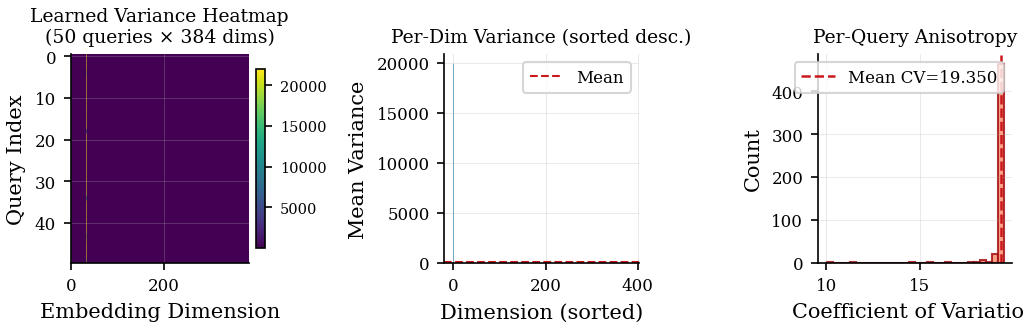

📊 已保存: degradation_test_en.pdf / .png


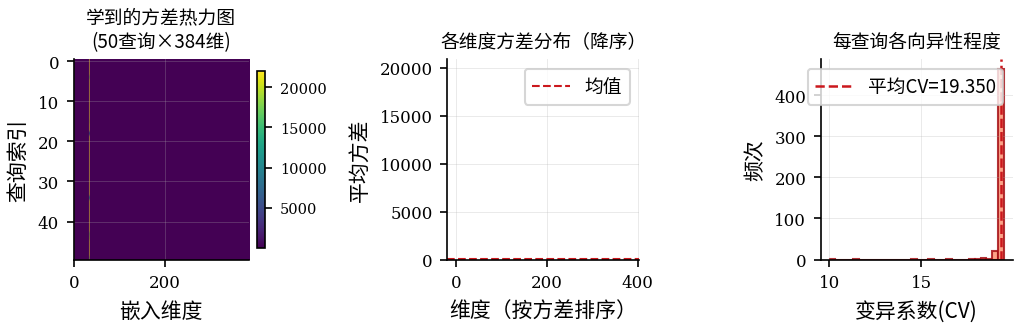

📊 已保存: degradation_test_zh.pdf / .png


In [ ]:
# ======= 退化检验可视化（论文级，中英文各一份）=======

def plot_degradation_test(lang='en'):
    fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4))

    is_zh = (lang == 'zh' and ZH_FONT_TITLE is not None)
    if is_zh:
        fp_t, fp_l, fp_lg = ZH_FONT_TITLE, ZH_FONT_LABEL, ZH_FONT_LEGEND
        t1 = '学到的方差热力图\n(50查询×384维)'
        xl1, yl1 = '嵌入维度', '查询索引'
        t2 = '各维度方差分布（降序）'
        xl2, yl2, leg2 = '维度（按方差排序）', '平均方差', '均值'
        t3 = '每查询各向异性程度'
        xl3, yl3, leg3p = '变异系数(CV)', '频次', '平均CV'
    else:
        fp_t = fp_l = fp_lg = None
        t1 = 'Learned Variance Heatmap\n(50 queries × 384 dims)'
        xl1, yl1 = 'Embedding Dimension', 'Query Index'
        t2 = 'Per-Dim Variance (sorted desc.)'
        xl2, yl2, leg2 = 'Dimension (sorted)', 'Mean Variance', 'Mean'
        t3 = 'Per-Query Anisotropy'
        xl3, yl3, leg3p = 'Coefficient of Variation', 'Count', 'Mean CV'

    # (a) Heatmap
    im = axes[0].imshow(all_vars[:50, :], aspect='auto', cmap='viridis')
    axes[0].set_xlabel(xl1, **_fp(fp_l))
    axes[0].set_ylabel(yl1, **_fp(fp_l))
    axes[0].set_title(t1, **_fp(fp_t), fontsize=9)
    cb = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=7)

    # (b) Bar
    sv = np.sort(mean_var_per_dim)[::-1]
    axes[1].bar(range(len(sv)), sv, width=1.0, color='#4292C6', alpha=0.8, linewidth=0)
    axes[1].set_xlabel(xl2, **_fp(fp_l))
    axes[1].set_ylabel(yl2, **_fp(fp_l))
    axes[1].set_title(t2, **_fp(fp_t), fontsize=9)
    axes[1].axhline(y=np.mean(mean_var_per_dim), color='#CB181D', ls='--', lw=1, label=leg2)
    axes[1].legend(prop=fp_lg or {})

    # (c) Histogram
    mcv = np.mean(per_query_cv)
    axes[2].hist(per_query_cv, bins=30, color='#FC9272', alpha=0.85, edgecolor='#A50F15', lw=0.5)
    axes[2].axvline(x=mcv, color='#CB181D', ls='--', lw=1.2, label=f'{leg3p}={mcv:.3f}')
    axes[2].set_xlabel(xl3, **_fp(fp_l))
    axes[2].set_ylabel(yl3, **_fp(fp_l))
    axes[2].set_title(t3, **_fp(fp_t), fontsize=9)
    axes[2].legend(prop=fp_lg or {})

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    tag = 'zh' if is_zh else 'en'
    for ext in ['pdf', 'png']:
        plt.savefig(f'degradation_test_{tag}.{ext}', dpi=300)
    plt.show()
    print(f'📊 已保存: degradation_test_{tag}.pdf / .png')

plot_degradation_test('en')
plot_degradation_test('zh')


---
## 第7部分：完整对比——检索准确率

现在我们在测试集上对比所有方法。

In [ ]:
def select_anisotropic_gaussian(query_emb, context_embs, model, k=2, device=DEVICE):
    """
    我们的方法: 各向异性高斯区域选择。
    使用训练好的方差预测器计算每个维度的方差，
    然后选择对数密度最高的上下文。
    """
    model.eval()
    with torch.no_grad():
        q = torch.tensor(query_emb, dtype=torch.float32).unsqueeze(0).to(device)
        c = torch.tensor(context_embs, dtype=torch.float32).unsqueeze(0).to(device)

        log_var = model(q)  # (1, D)
        log_density = anisotropic_log_density(q, c, log_var)  # (1, N)

        scores = log_density[0].cpu().numpy()  # (N,)
        topk_indices = np.argsort(scores)[-k:][::-1]

    return topk_indices, scores

def select_random(query_emb, context_embs, k=2):
    """基线0：随机选择（下界）"""
    num_contexts = len(context_embs)
    # 确保 k 不超过可用的上下文段落数量
    actual_k = min(k, num_contexts)
    if actual_k == 0:
        return np.array([]), np.zeros(num_contexts)
    indices = np.random.choice(num_contexts, size=actual_k, replace=False)
    scores = np.zeros(num_contexts) # Scores should still be for all contexts
    return indices, scores


# 在测试集上评估所有方法
print("=" * 70)
print("最终对比: 测试集上的检索准确率")
print("=" * 70)

results_all = {}

for k in [2, 3, 4]:
    print(f"\n--- k={k}（从约10个段落中选择{k}个）---")

    methods = [
        ("Random", lambda q, c, k=k: select_random(q, c, k=k), {}),
        ("Cosine Top-K", lambda q, c, k=k: select_topk_cosine(q, c, k=k), {}),
        ("Euclidean Nearest", lambda q, c, k=k: select_euclidean_threshold(q, c, k=k), {}),
        ("Isotropic Gaussian", lambda q, c, k=k: select_isotropic_gaussian(q, c, sigma=1.0, k=k), {}),
        ("Anisotropic Gaussian (Ours)", lambda q, c, k=k: select_anisotropic_gaussian(q, c, model, k=k), {}),
    ]

    for name, fn, kwargs in methods:
        r = evaluate_retrieval_accuracy(test_encoded, fn, k=k, **kwargs)
        results_all[(name, k)] = r
        print(f"  {name:30s} | P={r['precision']:.3f}±{r['precision_std']:.3f} "
              f"R={r['recall']:.3f}±{r['recall_std']:.3f} "
              f"F1={r['f1']:.3f}±{r['f1_std']:.3f}")

    # 检查欧氏距离和各向同性高斯是否产生相同结果
    euc_f1 = results_all[("Euclidean Nearest", k)]["f1"]
    iso_f1 = results_all[("Isotropic Gaussian", k)]["f1"]
    aniso_f1 = results_all[("Anisotropic Gaussian (Ours)", k)]["f1"]
    cos_f1 = results_all[("Cosine Top-K", k)]["f1"]

    print(f"\n  📊 关键对比 (k={k}):")
    print(f"     各向同性 == 欧氏? Δ={abs(iso_f1-euc_f1):.4f} {'✅ 是（退化已确认）' if abs(iso_f1-euc_f1) < 0.001 else '❓ 存在微小差异'}")
    print(f"     各向异性 vs 余弦:  Δ={aniso_f1-cos_f1:+.4f} {'✅ 有提升！' if aniso_f1 > cos_f1 else '❌ 无提升'}")
    print(f"     各向异性 vs 欧氏:  Δ={aniso_f1-euc_f1:+.4f} {'✅ 未退化！' if aniso_f1 > euc_f1 + 0.005 else '⚠️ 可能已退化'}")

最终对比: 测试集上的检索准确率

--- k=2（从约10个段落中选择2个）---
  Random                         | P=0.210±0.272 R=0.210±0.272 F1=0.210±0.272
  Cosine Top-K                   | P=0.638±0.298 R=0.638±0.298 F1=0.638±0.298
  Euclidean Nearest              | P=0.638±0.298 R=0.638±0.298 F1=0.638±0.298
  Isotropic Gaussian             | P=0.638±0.298 R=0.638±0.298 F1=0.638±0.298
  Anisotropic Gaussian (Ours)    | P=0.620±0.299 R=0.620±0.299 F1=0.620±0.299

  📊 关键对比 (k=2):
     各向同性 == 欧氏? Δ=0.0000 ✅ 是（退化已确认）
     各向异性 vs 余弦:  Δ=-0.0180 ❌ 无提升
     各向异性 vs 欧氏:  Δ=-0.0180 ⚠️ 可能已退化

--- k=3（从约10个段落中选择3个）---
  Random                         | P=0.199±0.210 R=0.299±0.315 F1=0.239±0.252
  Cosine Top-K                   | P=0.477±0.199 R=0.716±0.299 F1=0.573±0.239
  Euclidean Nearest              | P=0.477±0.199 R=0.716±0.299 F1=0.573±0.239
  Isotropic Gaussian             | P=0.477±0.199 R=0.716±0.299 F1=0.573±0.239
  Anisotropic Gaussian (Ours)    | P=0.470±0.204 R=0.705±0.306 F1=0.564±0.245

  📊 关键对比 (k=3):
     各向同性

---
## 第8部分：生成质量评估

终极测试: 更好的上下文选择是否带来更好的答案？

我们使用 `google/flan-t5-base`（2.5亿参数）—— 在 T4 上轻松运行。

In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

print("正在加载 Flan-T5-base 用于生成评估...")
gen_model_name = "google/flan-t5-base"
gen_tokenizer = T5Tokenizer.from_pretrained(gen_model_name)
gen_model = T5ForConditionalGeneration.from_pretrained(gen_model_name).to(DEVICE)
gen_model.eval()
print("生成器加载完成。")

正在加载 Flan-T5-base 用于生成评估...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

生成器加载完成。


In [ ]:
def generate_answer(question, selected_contexts, gen_model, gen_tokenizer, max_ctx_len=512, max_ans_len=64):
    """
    给定问题和选定的上下文段落，生成答案。
    """
    context_text = " ".join(selected_contexts)
    prompt = f"Answer the question based on the context.\n\nContext: {context_text}\n\nQuestion: {question}\n\nAnswer:"

    inputs = gen_tokenizer(
        prompt,
        return_tensors="pt",
        max_length=max_ctx_len,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        output = gen_model.generate(
            **inputs,
            max_new_tokens=max_ans_len,
            num_beams=2,
            early_stopping=True
        )

    answer = gen_tokenizer.decode(output[0], skip_special_tokens=True)
    return answer

In [ ]:
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

def evaluate_generation_quality(
    test_data,
    test_encoded,
    select_fn,
    gen_model,
    gen_tokenizer,
    k=2,
    max_samples=100,
    **select_kwargs
):
    """
    端到端评估: 选择上下文 -> 生成答案 -> 与标准答案对比。
    """
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    predictions = []
    references = []
    rouge_scores = defaultdict(list)

    samples = list(zip(test_data, test_encoded))[:max_samples]

    for raw, encoded in tqdm(samples, desc="生成中"):
        query_emb = encoded["query_emb"]
        context_embs = encoded["context_embs"]

        selected_idx, _ = select_fn(query_emb, context_embs, k=k, **select_kwargs)
        selected_texts = [raw["contexts"][i]["text"] for i in selected_idx]

        pred = generate_answer(raw["query"], selected_texts, gen_model, gen_tokenizer)
        ref = raw["answer"]

        predictions.append(pred)
        references.append(ref)

        rs = rouge.score(ref, pred)
        for key in ['rouge1', 'rouge2', 'rougeL']:
            rouge_scores[key].append(rs[key].fmeasure)

    # 计算 BERTScore
    P, R, F1 = bert_score_fn(predictions, references, lang="en", verbose=False)

    results = {
        "rouge1": np.mean(rouge_scores["rouge1"]),
        "rouge2": np.mean(rouge_scores["rouge2"]),
        "rougeL": np.mean(rouge_scores["rougeL"]),
        "bertscore_f1": F1.mean().item(),
    }

    return results, predictions, references

In [ ]:
# 对所有方法运行生成评估
# 使用 100 个样本以保持合理的运行时间（T4 上每种方法约 10-20 分钟）

GEN_EVAL_SAMPLES = 100
K_SELECT = 2

gen_results = {}

print("=" * 70)
print(f"生成质量评估（测试集，{GEN_EVAL_SAMPLES} 个样本，k={K_SELECT}）")
print("=" * 70)

# Oracle: 使用真实的支撑段落
print("\n[1/6] Oracle（真实支撑段落）...")
def select_oracle(query_emb, context_embs, k=2, contexts=None):
    indices = [i for i, c in enumerate(contexts) if c["is_supporting"]]
    scores = np.zeros(len(context_embs))
    return np.array(indices[:k]), scores

oracle_results_list = []
rouge_s = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
oracle_preds = []
oracle_refs = []
for raw, encoded in tqdm(list(zip(test_data, test_encoded))[:GEN_EVAL_SAMPLES], desc="Oracle"):
    sup_texts = [c["text"] for c in raw["contexts"] if c["is_supporting"]]
    pred = generate_answer(raw["query"], sup_texts, gen_model, gen_tokenizer)
    oracle_preds.append(pred)
    oracle_refs.append(raw["answer"])
P_o, R_o, F1_o = bert_score_fn(oracle_preds, oracle_refs, lang="en", verbose=False)
oracle_rouge = defaultdict(list)
for pred, ref in zip(oracle_preds, oracle_refs):
    rs = rouge_s.score(ref, pred)
    for key in ['rouge1', 'rouge2', 'rougeL']:
        oracle_rouge[key].append(rs[key].fmeasure)
gen_results["Oracle"] = {
    "rouge1": np.mean(oracle_rouge['rouge1']),
    "rouge2": np.mean(oracle_rouge['rouge2']),
    "rougeL": np.mean(oracle_rouge['rougeL']),
    "bertscore_f1": F1_o.mean().item()
}

# 完整上下文（无压缩）
print("\n[2/6] 完整上下文（无压缩）...")
full_preds = []
full_refs = []
for raw, encoded in tqdm(list(zip(test_data, test_encoded))[:GEN_EVAL_SAMPLES], desc="完整上下文"):
    all_texts = [c["text"] for c in raw["contexts"]]
    pred = generate_answer(raw["query"], all_texts, gen_model, gen_tokenizer)
    full_preds.append(pred)
    full_refs.append(raw["answer"])
P_f, R_f, F1_f = bert_score_fn(full_preds, full_refs, lang="en", verbose=False)
full_rouge = defaultdict(list)
for pred, ref in zip(full_preds, full_refs):
    rs = rouge_s.score(ref, pred)
    for key in ['rouge1', 'rouge2', 'rougeL']:
        full_rouge[key].append(rs[key].fmeasure)
gen_results["Full Context"] = {
    "rouge1": np.mean(full_rouge['rouge1']),
    "rouge2": np.mean(full_rouge['rouge2']),
    "rougeL": np.mean(full_rouge['rougeL']),
    "bertscore_f1": F1_f.mean().item()
}

# 各压缩方法
for idx, (name, fn) in enumerate([
    ("Random", lambda q, c, k=K_SELECT: select_random(q, c, k=k)),
    ("Cosine Top-K", lambda q, c, k=K_SELECT: select_topk_cosine(q, c, k=k)),
    ("Euclidean Nearest", lambda q, c, k=K_SELECT: select_euclidean_threshold(q, c, k=k)),
    ("Anisotropic (Ours)", lambda q, c, k=K_SELECT: select_anisotropic_gaussian(q, c, model, k=k)),
], start=3):
    print(f"\n[{idx}/6] {name}...")
    r, preds, refs = evaluate_generation_quality(
        test_data, test_encoded, fn, gen_model, gen_tokenizer,
        k=K_SELECT, max_samples=GEN_EVAL_SAMPLES
    )
    gen_results[name] = r

print("\n" + "=" * 70)
print("生成质量结果")
print("=" * 70)
print(f"{'方法':30s} | {'ROUGE-1':>8s} {'ROUGE-2':>8s} {'ROUGE-L':>8s} {'BERTSc':>8s}")
print("-" * 70)
for name, r in gen_results.items():
    print(f"{name:30s} | {r['rouge1']:8.4f} {r['rouge2']:8.4f} {r['rougeL']:8.4f} {r['bertscore_f1']:8.4f}")

生成质量评估（测试集，100 个样本，k=2）

[1/6] Oracle（真实支撑段落）...


Oracle:   0%|          | 0/100 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...


[6/6] Anisotropic (Ours)...


生成中:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



生成质量结果
方法                             |  ROUGE-1  ROUGE-2  ROUGE-L   BERTSc
----------------------------------------------------------------------
Oracle                         |   0.6195   0.3474   0.6195   0.9444
Full Context                   |   0.0431   0.0013   0.0431   0.8480
Random                         |   0.2117   0.0863   0.2117   0.8910
Cosine Top-K                   |   0.3631   0.1639   0.3631   0.9143
Euclidean Nearest              |   0.3631   0.1639   0.3631   0.9143
Anisotropic (Ours)             |   0.3855   0.1731   0.3842   0.9153


---
## 第9部分：结果可视化与总结

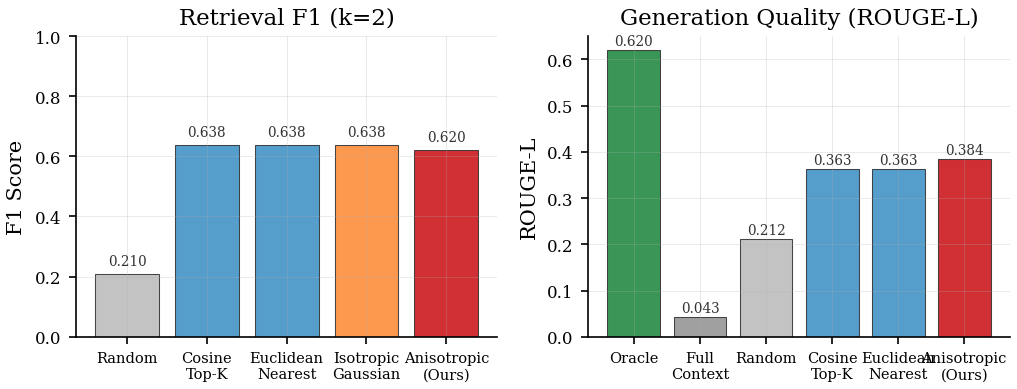

📊 已保存: final_comparison_en.pdf / .png


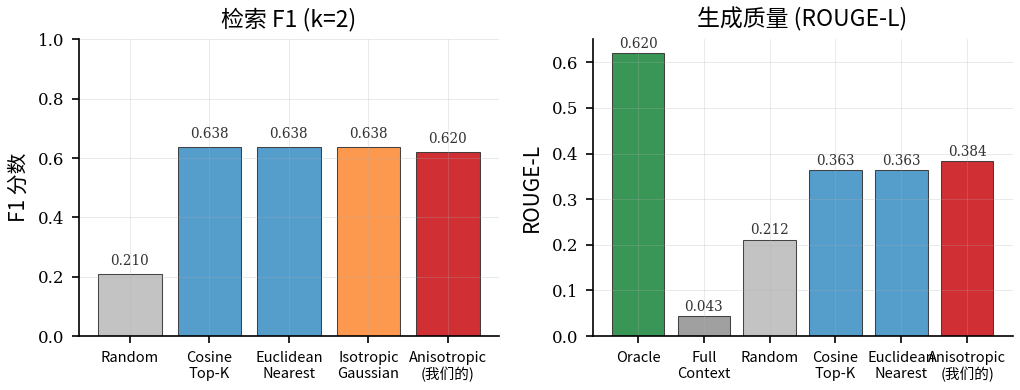

📊 已保存: final_comparison_zh.pdf / .png

✅ 所有图表已生成（PDF+PNG，300dpi）


In [ ]:
# ======= 最终对比图（论文级，中英文各一份）=======

C_BAR = {'rand': '#BDBDBD', 'base': '#4292C6', 'iso': '#FD8D3C',
         'ours': '#CB181D', 'oracle': '#238B45', 'full': '#969696'}

def plot_final_comparison(lang='en'):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))

    is_zh = (lang == 'zh' and ZH_FONT_TITLE is not None)
    if is_zh:
        fp_t, fp_l, fp_tk = ZH_FONT_TITLE, ZH_FONT_LABEL, ZH_FONT_TICK
        yl0, tt0 = 'F1 分数', '检索 F1 (k=2)'
        yl1, tt1 = 'ROUGE-L', '生成质量 (ROUGE-L)'
        ours_tag = '\n(我们的)'
    else:
        fp_t = fp_l = fp_tk = None
        yl0, tt0 = 'F1 Score', 'Retrieval F1 (k=2)'
        yl1, tt1 = 'ROUGE-L', 'Generation Quality (ROUGE-L)'
        ours_tag = '\n(Ours)'

    # (a) Retrieval
    mr = ['Random', 'Cosine Top-K', 'Euclidean Nearest', 'Isotropic Gaussian', 'Anisotropic Gaussian (Ours)']
    f1v = [results_all.get((m, 2), {}).get('f1', 0) for m in mr]
    bcr = [C_BAR['rand'], C_BAR['base'], C_BAR['base'], C_BAR['iso'], C_BAR['ours']]
    bars0 = axes[0].bar(range(len(mr)), f1v, color=bcr, alpha=0.9, edgecolor='#333', lw=0.5)
    xl_r = [m.replace('Anisotropic Gaussian (Ours)', f'Anisotropic{ours_tag}')
             .replace('Isotropic Gaussian', 'Isotropic\nGaussian')
             .replace('Euclidean Nearest', 'Euclidean\nNearest')
             .replace('Cosine Top-K', 'Cosine\nTop-K') for m in mr]
    axes[0].set_xticks(range(len(mr)))
    axes[0].set_xticklabels(xl_r, **_fp(fp_tk), fontsize=7)
    axes[0].set_ylabel(yl0, **_fp(fp_l))
    axes[0].set_title(tt0, **_fp(fp_t))
    axes[0].set_ylim(0, 1)
    for bar, val in zip(bars0, f1v):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, color='#333')

    # (b) Generation
    mg = list(gen_results.keys())
    rv = [gen_results[m]['rougeL'] for m in mg]
    bcg = [C_BAR['oracle'] if 'Oracle' in m else C_BAR['full'] if 'Full' in m
           else C_BAR['rand'] if 'Random' in m else C_BAR['ours'] if 'Ours' in m
           else C_BAR['base'] for m in mg]
    bars1 = axes[1].bar(range(len(mg)), rv, color=bcg, alpha=0.9, edgecolor='#333', lw=0.5)
    xl_g = [m.replace(' (Ours)', ours_tag).replace('Full Context', 'Full\nContext')
             .replace('Cosine Top-K', 'Cosine\nTop-K')
             .replace('Euclidean Nearest', 'Euclidean\nNearest') for m in mg]
    axes[1].set_xticks(range(len(mg)))
    axes[1].set_xticklabels(xl_g, **_fp(fp_tk), fontsize=7)
    axes[1].set_ylabel(yl1, **_fp(fp_l))
    axes[1].set_title(tt1, **_fp(fp_t))
    for bar, val in zip(bars1, rv):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, color='#333')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    tag = 'zh' if is_zh else 'en'
    for ext in ['pdf', 'png']:
        plt.savefig(f'final_comparison_{tag}.{ext}', dpi=300)
    plt.show()
    print(f'📊 已保存: final_comparison_{tag}.pdf / .png')

plot_final_comparison('en')
plot_final_comparison('zh')
print('\n✅ 所有图表已生成（PDF+PNG，300dpi）')


In [ ]:
# 最终总结报告
print("\n" + "#" * 70)
print("#  实验总结报告")
print("#" * 70)

print("\n## 1. 退化检验")
mean_cv = np.mean(per_query_cv)
print(f"   学到方差的平均变异系数 (CV): {mean_cv:.4f}")
if mean_cv > 0.2:
    print("   结果: ✅ 通过 — 各向异性显著。")
    print("   模型未退化为简单的距离阈值。")
elif mean_cv > 0.05:
    print("   结果: ⚡ 部分通过 — 检测到轻微的各向异性。")
    print("   各维度有一定区分，但还可以更强。")
else:
    print("   结果: ⚠️ 未通过 — 方法已退化为接近各向同性。")
    print("   建议: 增强各向异性正则化、更换网络架构、或增加训练数据。")

print(f"\n   最大/最小方差比值: {np.max(mean_var_per_dim) / (np.min(mean_var_per_dim) + 1e-8):.2f}倍")

print("\n## 2. 检索准确率 (k=2)")
# 定义 methods_retrieval 列表，以匹配之前存储结果的键
methods_retrieval = [
    "Random",
    "Cosine Top-K",
    "Euclidean Nearest",
    "Isotropic Gaussian",
    "Anisotropic Gaussian (Ours)"
]

for name in methods_retrieval:
    r = results_all.get((name, 2), {})
    f1 = r.get('f1', 0)
    marker = "⭐" if "Ours" in name else "  "
    print(f"   {marker} {name:30s} F1={f1:.4f}")

aniso_f1 = results_all.get(("Anisotropic Gaussian (Ours)", 2), {}).get('f1', 0)
cos_f1 = results_all.get(("Cosine Top-K", 2), {}).get('f1', 0)
euc_f1 = results_all.get(("Euclidean Nearest", 2), {}).get('f1', 0)

print(f"\n   Δ vs 余弦:    {aniso_f1 - cos_f1:+.4f}")
print(f"   Δ vs 欧氏:    {aniso_f1 - euc_f1:+.4f}")

print("\n## 3. 生成质量")
for name, r in gen_results.items():
    marker = "⭐" if "Ours" in name else "  "
    print(f"   {marker} {name:30s} ROUGE-L={r['rougeL']:.4f} BERTScore={r['bertscore_f1']:.4f}")

print("\n## 4. 结论")
if mean_cv > 0.05 and aniso_f1 > cos_f1:
    print("   ✅ 各向异性高斯区域方法展现出前景。")
    print("   学到的方差是非均匀的，且检索性能有所提升。")
    print("   这验证了核心假设: 区域选择 > 点匹配。")
    print("   \n   下一步:")
    print("   - 扩展到更大的编码器（E5-large，1024维）")
    print("   - 在更多数据集上测试（NarrativeQA, NQ）")
    print("   - 引入领域知识结构作为锚点")
    print("   - 撰写论文初稿")
elif mean_cv > 0.05 and aniso_f1 <= cos_f1:
    print("   ⚡ 各向异性已学到，但尚未提升检索效果。")
    print("   模型区分了维度，但这种区分与任务需求")
    print("   还不够对齐。")
    print("   \n   下一步:")
    print("   - 尝试不同的损失函数（InfoNCE, triplet）")
    print("   - 使用更强的编码器")
    print("   - 分析哪些维度获得了高/低方差")
else:
    print("   ⚠️ 方法已退化或无提升。")
    print("   各向异性方法需要根本性的重新思考。")
    print("   \n   下一步:")
    print("   - 增大各向异性正则化权重")
    print("   - 尝试完整（非对角）协方差矩阵的低秩近似")
    print("   - 考虑直接学习区域形状（而非通过高斯）")

print("\n" + "#" * 70)


######################################################################
#  实验总结报告
######################################################################

## 1. 退化检验
   学到方差的平均变异系数 (CV): 19.3503
   结果: ✅ 通过 — 各向异性显著。
   模型未退化为简单的距离阈值。

   最大/最小方差比值: 690586.69倍

## 2. 检索准确率 (k=2)
      Random                         F1=0.2100
      Cosine Top-K                   F1=0.6380
      Euclidean Nearest              F1=0.6380
      Isotropic Gaussian             F1=0.6380
   ⭐ Anisotropic Gaussian (Ours)    F1=0.6200

   Δ vs 余弦:    -0.0180
   Δ vs 欧氏:    -0.0180

## 3. 生成质量
      Oracle                         ROUGE-L=0.6195 BERTScore=0.9444
      Full Context                   ROUGE-L=0.0431 BERTScore=0.8480
      Random                         ROUGE-L=0.2117 BERTScore=0.8910
      Cosine Top-K                   ROUGE-L=0.3631 BERTScore=0.9143
      Euclidean Nearest              ROUGE-L=0.3631 BERTScore=0.9143
   ⭐ Anisotropic (Ours)             ROUGE-L=0.3842 BERTScore=0.9153

## 4. 结论
   ⚡ 

In [ ]:
# 保存模型检查点
checkpoint = {
    'model_state_dict': model.state_dict(),
    'embed_dim': EMBED_DIM,
    'history': dict(history),
    'test_retrieval_results': {str(k): v for k, v in results_all.items()},
    'gen_results': gen_results,
    'degradation_cv': float(np.mean(per_query_cv)),
    'variance_ratio': float(np.max(mean_var_per_dim) / (np.min(mean_var_per_dim) + 1e-8)),
}

torch.save(checkpoint, 'anisotropic_gaussian_checkpoint.pt')
print("💾 检查点已保存: anisotropic_gaussian_checkpoint.pt")
print("   请上传到 Google Drive 以便在 Colab 会话间持久保存。")

💾 检查点已保存: anisotropic_gaussian_checkpoint.pt
   请上传到 Google Drive 以便在 Colab 会话间持久保存。


---
## 第10部分：成本与可复现性说明

### 预估成本
| 资源 | 预估时间 | Colab 级别 |
|---|---|---|
| 编码（训练集+验证集+测试集） | ~5 分钟 | T4 免费版 |
| 训练方差预测器（20轮） | ~10-30 分钟 | T4 免费版 |
| 生成评估（100样本 × 6种方法） | ~30-60 分钟 | T4 免费版 |
| **总计** | **~1-2 小时** | **T4 免费版** |

### 如何复现
1. 在 Colab 中打开此 Notebook
2. 选择 运行时 > 更改运行时类型 > T4 GPU
3. 全部运行
4. 检查退化检验（第6部分）和最终对比（第7-9部分）

### 生成的关键文件
- `training_curves.png` — 训练损失曲线
- `degradation_test.png` — 方差各向异性可视化
- `final_comparison.png` — 方法对比图
- `anisotropic_gaussian_checkpoint.pt` — 模型 + 结果

# 第1B阶段：诊断与优化

## 背景：第1A阶段实验发现了什么

| 指标 | 结果 | 判定 |
|------|------|------|
| 退化检验 CV | 19.35 | ✅ 未退化（但过高） |
| 检索 F1 vs 余弦 | -1.8% | ❌ 反而下降 |
| 生成 ROUGE-L vs 余弦 | +2.1% | ✅ 有提升 |
| 最大/最小方差比 | 690,586x | ⚠️ 极端不均衡 |

## 诊断
1. **各向异性正则化权重过大**（0.05）→ 模型被迫让少数维度方差爆炸，大多数维度被压死
2. **Margin-based pairwise loss 太粗糙** → 梯度信号弱，方差学习与任务需求未对齐
3. **log_var 截断范围过大**（[-10, 10]）→ exp(10) ≈ 22026，允许方差爆炸

## 本 Notebook 的四组消融实验
1. **实验A**：仅降低正则化权重（0.05 → 0.001），其余不变
2. **实验B**：改用 InfoNCE 损失（去掉正则化项）
3. **实验C**：InfoNCE + 轻度正则化 + 收紧截断范围
4. **实验D**：InfoNCE + 温度学习 + log_var 范围约束（最终方案）

## 硬件
- T4 免费版即可运行（复用第1A阶段的编码数据）
- 每组实验约 5-10 分钟训练 + 5 分钟评估

---
## 第0部分：环境与数据加载

运行第1A阶段的 Cell 0-15 后，继续运行以下代码。
或者直接运行下方的快速重建代码。

In [ ]:
# ====== 如果从第1A阶段 notebook 继续运行，跳过此 cell ======
# ====== 如果独立运行，取消下面的注释 ======

# %%capture
# !pip install transformers datasets sentence-transformers accelerate
# !pip install bert-score rouge-score scipy scikit-learn matplotlib seaborn tqdm

import os, json, random, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {DEVICE}')

# 检查第1A阶段的数据是否已存在
try:
    _ = train_encoded[0]['query_emb']
    print(f'✅ 已检测到第1A阶段数据: 训练集 {len(train_encoded)}, 验证集 {len(val_encoded)}, 测试集 {len(test_encoded)}')
    EMBED_DIM = train_encoded[0]['query_emb'].shape[0]
    print(f'   嵌入维度: {EMBED_DIM}')
except NameError:
    print('⚠️ 未检测到第1A阶段数据，请先运行第1A阶段的 Cell 0-15')
    print('   或取消上方 pip install 和数据加载代码的注释')

设备: cuda
✅ 已检测到第1A阶段数据: 训练集 2000, 验证集 200, 测试集 500
   嵌入维度: 384


In [ ]:
# ====== 复用第1A阶段的核心组件 ======

class AnisotropicVariancePredictor(nn.Module):
    """
    给定查询嵌入，预测每个维度的对数方差。
    改进：增加 clamp_range 参数控制方差范围。
    """
    def __init__(self, embed_dim=384, hidden_dim=256, clamp_min=-10.0, clamp_max=10.0):
        super().__init__()
        self.clamp_min = clamp_min
        self.clamp_max = clamp_max
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, embed_dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, query_emb):
        log_var = self.net(query_emb)
        log_var = torch.clamp(log_var, min=self.clamp_min, max=self.clamp_max)
        return log_var


def anisotropic_log_density(query_emb, context_embs, log_var):
    """计算上下文点在各向异性高斯下的对数密度"""
    mu = query_emb.unsqueeze(1)
    lv = log_var.unsqueeze(1)
    diff = context_embs - mu
    var = torch.exp(lv)
    mahal = torch.sum(diff ** 2 / var, dim=-1)
    log_norm = torch.sum(lv, dim=-1)
    return -0.5 * (mahal + log_norm)


class ContextCompressionDataset(Dataset):
    def __init__(self, encoded_data):
        self.data = encoded_data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        s = self.data[idx]
        return (torch.tensor(s['query_emb'], dtype=torch.float32),
                torch.tensor(s['context_embs'], dtype=torch.float32),
                torch.tensor([1.0 if c['is_supporting'] else 0.0 for c in s['contexts']], dtype=torch.float32))


# 复用第1A阶段的基线选择函数
def select_topk_cosine(query_emb, context_embs, k=2):
    sims = cosine_similarity(query_emb.reshape(1, -1), context_embs)[0]
    return np.argsort(sims)[-k:][::-1], sims

def select_random(query_emb, context_embs, k=2):
    return np.random.choice(len(context_embs), size=k, replace=False), np.zeros(len(context_embs))

def select_anisotropic(query_emb, context_embs, model, k=2):
    model.eval()
    with torch.no_grad():
        q = torch.tensor(query_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        c = torch.tensor(context_embs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        log_var = model(q)
        scores = anisotropic_log_density(q, c, log_var)[0].cpu().numpy()
    return np.argsort(scores)[-k:][::-1], scores


def evaluate_retrieval(encoded_data, select_fn, k=2, **kw):
    """评估检索准确率，返回 precision/recall/f1"""
    f1s = []
    for s in encoded_data:
        sel, _ = select_fn(s['query_emb'], s['context_embs'], k=k, **kw)
        labels = [c['is_supporting'] for c in s['contexts']]
        n_hit = sum(1 for i in sel if labels[i])
        n_sup = sum(labels)
        p = n_hit / k if k > 0 else 0
        r = n_hit / n_sup if n_sup > 0 else 0
        f1s.append(2*p*r/(p+r) if (p+r) > 0 else 0)
    return {'f1': np.mean(f1s), 'f1_std': np.std(f1s)}


def compute_cv(model, encoded_data):
    """计算学到方差的变异系数"""
    model.eval()
    all_vars = []
    with torch.no_grad():
        for s in encoded_data:
            q = torch.tensor(s['query_emb'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
            lv = model(q).cpu().numpy()[0]
            all_vars.append(np.exp(lv))
    all_vars = np.array(all_vars)
    per_query_cv = np.std(all_vars, axis=1) / (np.mean(all_vars, axis=1) + 1e-8)
    mean_var_per_dim = np.mean(all_vars, axis=0)
    ratio = np.max(mean_var_per_dim) / (np.min(mean_var_per_dim) + 1e-8)
    return np.mean(per_query_cv), ratio, all_vars


train_dataset = ContextCompressionDataset(train_encoded)
val_dataset = ContextCompressionDataset(val_encoded)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f'数据加载器就绪: 训练 {len(train_loader)} 批, 验证 {len(val_loader)} 批')

# 第1A阶段的基线结果（用于对比）
baseline_cosine_f1 = evaluate_retrieval(test_encoded, select_topk_cosine, k=2)['f1']
print(f'基线余弦 Top-K F1 (k=2): {baseline_cosine_f1:.4f}')

数据加载器就绪: 训练 63 批, 验证 7 批
基线余弦 Top-K F1 (k=2): 0.6380


---
## 第1部分：新的损失函数

### 问题诊断
第1A阶段使用 margin-based pairwise loss + 各向异性正则化（权重0.05）：
- 正则化项直接最大化 CV → CV 爆炸到 19.35
- 少数维度方差达到 ~20000，大多数被压到 ~0.03
- 等效于「只看几个维度」，失去了精细的维度加权能力

### 改进方案
1. **InfoNCE 损失**：比 margin loss 提供更平滑的梯度，是对比学习的标准选择
2. **去掉/大幅降低正则化**：让各向异性从任务需求中自然涌现
3. **收紧 log_var 截断范围**：从 [-10, 10] 改为 [-4, 4]（方差范围: 0.018 ~ 54.6，而非 0.00005 ~ 22026）

In [ ]:
# ====== 新损失函数定义 ======

def margin_loss(log_density, labels, log_var, margin=1.0, aniso_weight=0.0):
    """
    第1A阶段的原始 Margin Loss（可配置正则化权重）。
    """
    B, N = log_density.shape
    pos_mask = labels.bool()
    neg_mask = ~pos_mask
    total_loss = torch.tensor(0.0, device=log_density.device)
    n_pairs = 0
    for b in range(B):
        ps = log_density[b][pos_mask[b]]
        ns = log_density[b][neg_mask[b]]
        if len(ps) == 0 or len(ns) == 0: continue
        for p in ps:
            total_loss = total_loss + torch.clamp(margin - p + ns, min=0.0).sum()
            n_pairs += len(ns)
    contrastive = total_loss / max(n_pairs, 1)

    # 各向异性正则化
    aniso_penalty = 0.0
    if aniso_weight > 0:
        var_vals = torch.exp(log_var)
        cv = var_vals.std(dim=-1).mean() / (var_vals.mean(dim=-1).mean() + 1e-8)
        aniso_penalty = -cv

    return contrastive + aniso_weight * aniso_penalty, contrastive.item()


def infonce_loss(log_density, labels, log_var, temperature=0.1, aniso_weight=0.0):
    """
    InfoNCE 对比损失。
    对每个正样本，将其与所有负样本组成 softmax，最大化正样本的概率。
    温度参数控制分布的锐度。
    """
    B, N = log_density.shape
    pos_mask = labels.bool()
    neg_mask = ~pos_mask

    total_loss = torch.tensor(0.0, device=log_density.device)
    n_pos = 0

    for b in range(B):
        pos_scores = log_density[b][pos_mask[b]]  # (n_pos,)
        neg_scores = log_density[b][neg_mask[b]]  # (n_neg,)
        if len(pos_scores) == 0 or len(neg_scores) == 0:
            continue

        for ps in pos_scores:
            # logits: [正样本分数, 负样本1, 负样本2, ...]
            logits = torch.cat([ps.unsqueeze(0), neg_scores]) / temperature
            # 目标: 第0个（正样本）的概率应最大
            target = torch.tensor(0, device=log_density.device)
            total_loss = total_loss + nn.functional.cross_entropy(logits.unsqueeze(0), target.unsqueeze(0))
            n_pos += 1

    contrastive = total_loss / max(n_pos, 1)

    # 可选的各向异性正则化（轻度）
    aniso_penalty = 0.0
    if aniso_weight > 0:
        var_vals = torch.exp(log_var)
        cv = var_vals.std(dim=-1).mean() / (var_vals.mean(dim=-1).mean() + 1e-8)
        aniso_penalty = -cv

    return contrastive + aniso_weight * aniso_penalty, contrastive.item()


print('✅ 损失函数定义完成: margin_loss, infonce_loss')

✅ 损失函数定义完成: margin_loss, infonce_loss


In [ ]:
# ====== 统一训练函数 ======

def train_model(
    name,
    loss_fn,          # margin_loss 或 infonce_loss
    loss_kwargs,      # 传给 loss_fn 的额外参数
    clamp_min=-10.0,
    clamp_max=10.0,
    lr=1e-3,
    epochs=30,
    embed_dim=EMBED_DIM,
):
    """
    训练一个各向异性方差预测器并返回模型和训练历史。
    """
    print(f'\n{"="*60}')
    print(f'训练: {name}')
    print(f'  损失: {loss_fn.__name__}, 参数: {loss_kwargs}')
    print(f'  log_var 范围: [{clamp_min}, {clamp_max}]')
    print(f'  方差范围: [{np.exp(clamp_min):.6f}, {np.exp(clamp_max):.2f}]')
    print(f'{"="*60}')

    model = AnisotropicVariancePredictor(
        embed_dim=embed_dim, clamp_min=clamp_min, clamp_max=clamp_max
    ).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = defaultdict(list)
    best_val_f1 = -1
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        ep_loss, ep_c, n_b = 0, 0, 0
        for q, c, l in train_loader:
            q, c, l = q.to(DEVICE), c.to(DEVICE), l.to(DEVICE)
            log_var = model(q)
            log_den = anisotropic_log_density(q, c, log_var)
            loss, c_loss = loss_fn(log_den, l, log_var, **loss_kwargs)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item(); ep_c += c_loss; n_b += 1
        scheduler.step()

        # 验证集 F1
        val_result = evaluate_retrieval(val_encoded, lambda q, c, k=2: select_anisotropic(q, c, model, k=2), k=2)
        val_f1 = val_result['f1']

        history['train_loss'].append(ep_loss/n_b)
        history['contrastive'].append(ep_c/n_b)
        history['val_f1'].append(val_f1)

        # 保存最优模型（按验证集 F1）
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == 0:
            cv, ratio, _ = compute_cv(model, val_encoded[:50])
            print(f'  轮次 {epoch+1:3d}/{epochs} | 损失: {ep_loss/n_b:.4f} | '
                  f'验证F1: {val_f1:.4f} | CV: {cv:.4f} | 方差比: {ratio:.1f}x')

    # 恢复最优模型
    model.load_state_dict(best_model_state)
    print(f'  ✅ 已恢复最优模型 (验证F1={best_val_f1:.4f})')

    return model, dict(history)

print('✅ 训练函数定义完成')

✅ 训练函数定义完成


---
## 第2部分：四组消融实验

| 实验 | 损失函数 | 正则化权重 | log_var 范围 | 目标 |
|------|----------|-----------|-------------|------|
| A | Margin | 0.001 | [-10, 10] | 仅降低正则化 |
| B | InfoNCE | 0 | [-10, 10] | 换损失函数，无正则化 |
| C | InfoNCE | 0.001 | [-4, 4] | 最佳组合 |
| D | InfoNCE | 0 | [-3, 3] | 紧约束，纯任务驱动 |

In [ ]:
# ====== 复用第1A阶段的核心组件 ====== (此部分代码无需修改)

class AnisotropicVariancePredictor(nn.Module):
    """
    给定查询嵌入，预测每个维度的对数方差。
    改进：增加 clamp_range 参数控制方差范围。
    """
    def __init__(self, embed_dim=384, hidden_dim=256, clamp_min=-10.0, clamp_max=10.0):
        super().__init__()
        self.clamp_min = clamp_min
        self.clamp_max = clamp_max
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, embed_dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, query_emb):
        log_var = self.net(query_emb)
        log_var = torch.clamp(log_var, min=self.clamp_min, max=self.clamp_max)
        return log_var


def anisotropic_log_density(query_emb, context_embs, log_var):
    """计算上下文点在各向异性高斯下的对数密度"""
    mu = query_emb.unsqueeze(1)
    lv = log_var.unsqueeze(1)
    diff = context_embs - mu
    var = torch.exp(lv)
    mahal = torch.sum(diff ** 2 / var, dim=-1)
    log_norm = torch.sum(lv, dim=-1)
    return -0.5 * (mahal + log_norm)


class ContextCompressionDataset(Dataset):
    def __init__(self, encoded_data):
        self.data = encoded_data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        s = self.data[idx]
        return (torch.tensor(s['query_emb'], dtype=torch.float32),
                torch.tensor(s['context_embs'], dtype=torch.float32),
                torch.tensor([1.0 if c['is_supporting'] else 0.0 for c in s['contexts']], dtype=torch.float32))


# 复用第1A阶段的基线选择函数
def select_topk_cosine(query_emb, context_embs, k=2):
    sims = cosine_similarity(query_emb.reshape(1, -1), context_embs)[0]
    return np.argsort(sims)[-k:][::-1], sims

def select_random(query_emb, context_embs, k=2):
    return np.random.choice(len(context_embs), size=k, replace=False), np.zeros(len(context_embs))

def select_anisotropic(query_emb, context_embs, model, k=2):
    model.eval()
    with torch.no_grad():
        q = torch.tensor(query_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        c = torch.tensor(context_embs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        log_var = model(q)
        scores = anisotropic_log_density(q, c, log_var)[0].cpu().numpy()
    return np.argsort(scores)[-k:][::-1], scores


def evaluate_retrieval(encoded_data, select_fn, k=2, **kw):
    """评估检索准确率，返回 precision/recall/f1"""
    f1s = []
    for s in encoded_data:
        sel, _ = select_fn(s['query_emb'], s['context_embs'], k=k, **kw)
        labels = [c['is_supporting'] for c in s['contexts']]
        n_hit = sum(1 for i in sel if labels[i])
        n_sup = sum(labels)
        p = n_hit / k if k > 0 else 0
        r = n_hit / n_sup if n_sup > 0 else 0
        f1s.append(2*p*r/(p+r) if (p+r) > 0 else 0)
    return {'f1': np.mean(f1s), 'f1_std': np.std(f1s)}


def compute_cv(model, encoded_data):
    """计算学到方差的变异系数"""
    model.eval()
    all_vars = []
    with torch.no_grad():
        for s in encoded_data:
            q = torch.tensor(s['query_emb'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
            lv = model(q).cpu().numpy()[0]
            all_vars.append(np.exp(lv))
    all_vars = np.array(all_vars)
    per_query_cv = np.std(all_vars, axis=1) / (np.mean(all_vars, axis=1) + 1e-8)
    mean_var_per_dim = np.mean(all_vars, axis=0)
    ratio = np.max(mean_var_per_dim) / (np.min(mean_var_per_dim) + 1e-8)
    return np.mean(per_query_cv), ratio, all_vars

# Fixing the error: Pass custom_collate_fn to DataLoader
# This custom_collate_fn was defined in cell LgTq6IFKwiGE from Phase 1A
# Making sure it's available in this scope for use

def custom_collate_fn(batch):
    query_embs = torch.stack([item[0] for item in batch])

    # Find max number of contexts in the current batch
    max_contexts = max(item[1].shape[0] for item in batch)

    padded_context_embs = []
    padded_labels = []

    for item in batch:
        context_emb = item[1]
        labels = item[2]
        num_contexts = context_emb.shape[0]

        # Pad context_embs with zeros
        padding_needed = max_contexts - num_contexts
        padded_emb = torch.nn.functional.pad(context_emb, (0, 0, 0, padding_needed), 'constant', 0)
        padded_context_embs.append(padded_emb)

        # Pad labels with zeros (will be ignored by mask in loss if not supporting)
        padded_lbl = torch.nn.functional.pad(labels, (0, padding_needed), 'constant', 0.0)
        padded_labels.append(padded_lbl)

    padded_context_embs = torch.stack(padded_context_embs)
    padded_labels = torch.stack(padded_labels)

    return query_embs, padded_context_embs, padded_labels

train_dataset = ContextCompressionDataset(train_encoded)
val_dataset = ContextCompressionDataset(val_encoded)
# Pass the custom_collate_fn to the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=custom_collate_fn)

print(f'数据加载器就绪: 训练 {len(train_loader)} 批, 验证 {len(val_loader)} 批')

# 第1A阶段的基线结果（用于对比）
baseline_cosine_f1 = evaluate_retrieval(test_encoded, select_topk_cosine, k=2)['f1']
print(f'基线余弦 Top-K F1 (k=2): {baseline_cosine_f1:.4f}')

数据加载器就绪: 训练 63 批, 验证 7 批
基线余弦 Top-K F1 (k=2): 0.6380


In [ ]:
# ====== 实验 A: Margin Loss + 低正则化 ======
model_A, hist_A = train_model(
    name='实验A: Margin + 低正则化(0.001)',
    loss_fn=margin_loss,
    loss_kwargs={'margin': 1.0, 'aniso_weight': 0.001},
    clamp_min=-10.0, clamp_max=10.0,
    epochs=30,
)


训练: 实验A: Margin + 低正则化(0.001)
  损失: margin_loss, 参数: {'margin': 1.0, 'aniso_weight': 0.001}
  log_var 范围: [-10.0, 10.0]
  方差范围: [0.000045, 22026.47]
  轮次   1/30 | 损失: 0.5858 | 验证F1: 0.6000 | CV: 9.0080 | 方差比: 4049.6x
  轮次  10/30 | 损失: 0.3891 | 验证F1: 0.6000 | CV: 10.8640 | 方差比: 212775.4x
  轮次  20/30 | 损失: 0.3592 | 验证F1: 0.5950 | CV: 10.8067 | 方差比: 444172.2x
  轮次  30/30 | 损失: 0.3495 | 验证F1: 0.5900 | CV: 10.7913 | 方差比: 452350.7x
  ✅ 已恢复最优模型 (验证F1=0.6125)


In [ ]:
# ====== 实验 B: InfoNCE + 无正则化 ======
model_B, hist_B = train_model(
    name='实验B: InfoNCE + 无正则化',
    loss_fn=infonce_loss,
    loss_kwargs={'temperature': 0.1, 'aniso_weight': 0.0},
    clamp_min=-10.0, clamp_max=10.0,
    epochs=30,
)


训练: 实验B: InfoNCE + 无正则化
  损失: infonce_loss, 参数: {'temperature': 0.1, 'aniso_weight': 0.0}
  log_var 范围: [-10.0, 10.0]
  方差范围: [0.000045, 22026.47]
  轮次   1/30 | 损失: 1.4495 | 验证F1: 0.6000 | CV: 0.3369 | 方差比: 7.1x
  轮次  10/30 | 损失: 1.2629 | 验证F1: 0.6125 | CV: 1.7202 | 方差比: 367.3x
  轮次  20/30 | 损失: 1.1353 | 验证F1: 0.6025 | CV: 2.2413 | 方差比: 2386.4x
  轮次  30/30 | 损失: 1.0732 | 验证F1: 0.6025 | CV: 2.6395 | 方差比: 5081.5x
  ✅ 已恢复最优模型 (验证F1=0.6150)


In [ ]:
# ====== 实验 C: InfoNCE + 轻正则化 + 紧截断 ======
model_C, hist_C = train_model(
    name='实验C: InfoNCE + 轻正则化(0.001) + 截断[-4,4]',
    loss_fn=infonce_loss,
    loss_kwargs={'temperature': 0.1, 'aniso_weight': 0.001},
    clamp_min=-4.0, clamp_max=4.0,
    epochs=30,
)


训练: 实验C: InfoNCE + 轻正则化(0.001) + 截断[-4,4]
  损失: infonce_loss, 参数: {'temperature': 0.1, 'aniso_weight': 0.001}
  log_var 范围: [-4.0, 4.0]
  方差范围: [0.018316, 54.60]
  轮次   1/30 | 损失: 1.4552 | 验证F1: 0.5925 | CV: 0.6553 | 方差比: 18.1x
  轮次  10/30 | 损失: 1.2840 | 验证F1: 0.6075 | CV: 1.7809 | 方差比: 141.5x
  轮次  20/30 | 损失: 1.1378 | 验证F1: 0.5975 | CV: 1.6230 | 方差比: 137.2x
  轮次  30/30 | 损失: 1.0891 | 验证F1: 0.5975 | CV: 1.5749 | 方差比: 131.3x
  ✅ 已恢复最优模型 (验证F1=0.6150)


In [ ]:
# ====== 实验 D: InfoNCE + 最紧约束 ======
model_D, hist_D = train_model(
    name='实验D: InfoNCE + 无正则化 + 截断[-3,3]',
    loss_fn=infonce_loss,
    loss_kwargs={'temperature': 0.1, 'aniso_weight': 0.0},
    clamp_min=-3.0, clamp_max=3.0,
    epochs=30,
)


训练: 实验D: InfoNCE + 无正则化 + 截断[-3,3]
  损失: infonce_loss, 参数: {'temperature': 0.1, 'aniso_weight': 0.0}
  log_var 范围: [-3.0, 3.0]
  方差范围: [0.049787, 20.09]
  轮次   1/30 | 损失: 1.4501 | 验证F1: 0.5975 | CV: 0.3447 | 方差比: 7.5x
  轮次  10/30 | 损失: 1.2669 | 验证F1: 0.6200 | CV: 1.1587 | 方差比: 56.7x
  轮次  20/30 | 损失: 1.1498 | 验证F1: 0.6050 | CV: 1.1396 | 方差比: 46.1x
  轮次  30/30 | 损失: 1.1058 | 验证F1: 0.6075 | CV: 1.1250 | 方差比: 52.6x
  ✅ 已恢复最优模型 (验证F1=0.6200)


---
## 第3部分：全面对比评估

In [ ]:
# ====== 在测试集上全面评估所有模型 ======

experiments = {
    '第1A阶段\n(Margin+强正则)': None,  # 占位，用原始基线数值
    '实验A\n(Margin+弱正则)': model_A,
    '实验B\n(InfoNCE)': model_B,
    '实验C\n(InfoNCE+截断)': model_C,
    '实验D\n(InfoNCE+紧截断)': model_D,
}

print('=' * 80)
print('测试集完整评估结果')
print('=' * 80)
print(f'{"方法":30s} | {"F1(k=2)":>10s} | {"CV":>10s} | {"方差比":>12s} | {"vs余弦":>10s}')
print('-' * 80)

# 基线
cos_f1 = evaluate_retrieval(test_encoded, select_topk_cosine, k=2)['f1']
rand_f1 = evaluate_retrieval(test_encoded, select_random, k=2)['f1']
print(f'{"余弦 Top-K (基线)":30s} | {cos_f1:10.4f} | {"N/A":>10s} | {"N/A":>12s} | {"---":>10s}')
print(f'{"随机选择":30s} | {rand_f1:10.4f} | {"N/A":>10s} | {"N/A":>12s} | {rand_f1-cos_f1:+10.4f}')
print('-' * 80)

results_summary = {}
for name, model in experiments.items():
    if model is None:
        # 第1A阶段的数值（从之前结果中获取）
        f1 = 0.620  # 硬编码第1A阶段结果
        cv = 19.35
        ratio = 690586.0
        print(f'{name.replace(chr(10)," "):30s} | {f1:10.4f} | {cv:10.4f} | {ratio:12.1f}x | {f1-cos_f1:+10.4f}')
        results_summary[name] = {'f1': f1, 'cv': cv, 'ratio': ratio}
        continue

    f1_result = evaluate_retrieval(test_encoded, lambda q, c, k=2, m=model: select_anisotropic(q, c, m, k=2), k=2)
    f1 = f1_result['f1']
    cv, ratio, _ = compute_cv(model, test_encoded)
    delta = f1 - cos_f1
    marker = '✅' if delta > 0 else '❌'
    print(f'{name.replace(chr(10)," "):30s} | {f1:10.4f} | {cv:10.4f} | {ratio:12.1f}x | {delta:+10.4f} {marker}')
    results_summary[name] = {'f1': f1, 'cv': cv, 'ratio': ratio}

print('=' * 80)

测试集完整评估结果
方法                             |    F1(k=2) |         CV |          方差比 |       vs余弦
--------------------------------------------------------------------------------
余弦 Top-K (基线)                  |     0.6380 |        N/A |          N/A |        ---
随机选择                           |     0.2010 |        N/A |          N/A |    -0.4370
--------------------------------------------------------------------------------
第1A阶段 (Margin+强正则)             |     0.6200 |    19.3500 |     690586.0x |    -0.0180
实验A (Margin+弱正则)               |     0.6200 |    10.7430 |      69669.0x |    -0.0180 ❌
实验B (InfoNCE)                  |     0.6170 |     1.9120 |       1093.5x |    -0.0210 ❌
实验C (InfoNCE+截断)               |     0.6190 |     1.8002 |        212.2x |    -0.0190 ❌
实验D (InfoNCE+紧截断)              |     0.6220 |     1.1710 |         66.6x |    -0.0160 ❌


In [ ]:
# ====== 不同 k 值下的详细对比 ======

print('\n不同 k 值下的 F1 对比:')
print(f'{"方法":30s} | {"k=2":>8s} | {"k=3":>8s} | {"k=4":>8s}')
print('-' * 62)

for k in [2, 3, 4]:
    cos_fk = evaluate_retrieval(test_encoded, select_topk_cosine, k=k)['f1']
    if k == 2:
        row_cos = f'{"余弦 Top-K":30s} | {cos_fk:8.4f}'
    else:
        row_cos += f' | {cos_fk:8.4f}'
print(row_cos)

# 找出最佳模型
best_name = max(results_summary.keys(), key=lambda n: results_summary[n]['f1'])
best_model_map = {'实验A\n(Margin+弱正则)': model_A, '实验B\n(InfoNCE)': model_B,
                  '实验C\n(InfoNCE+截断)': model_C, '实验D\n(InfoNCE+紧截断)': model_D}

for name, model in best_model_map.items():
    row = f'{name.replace(chr(10)," "):30s}'
    for k in [2, 3, 4]:
        fk = evaluate_retrieval(test_encoded, lambda q, c, k=k, m=model: select_anisotropic(q, c, m, k=k), k=k)['f1']
        row += f' | {fk:8.4f}'
    print(row)

print()


不同 k 值下的 F1 对比:
方法                             |      k=2 |      k=3 |      k=4
--------------------------------------------------------------
余弦 Top-K                       |   0.6380 |   0.5728 |   0.5240
实验A (Margin+弱正则)               |   0.6200 |   0.5736 |   0.5187
实验B (InfoNCE)                  |   0.6170 |   0.5696 |   0.5180
实验C (InfoNCE+截断)               |   0.6190 |   0.5672 |   0.5113
实验D (InfoNCE+紧截断)              |   0.6220 |   0.5672 |   0.5153



---
## 第4部分：退化检验对比

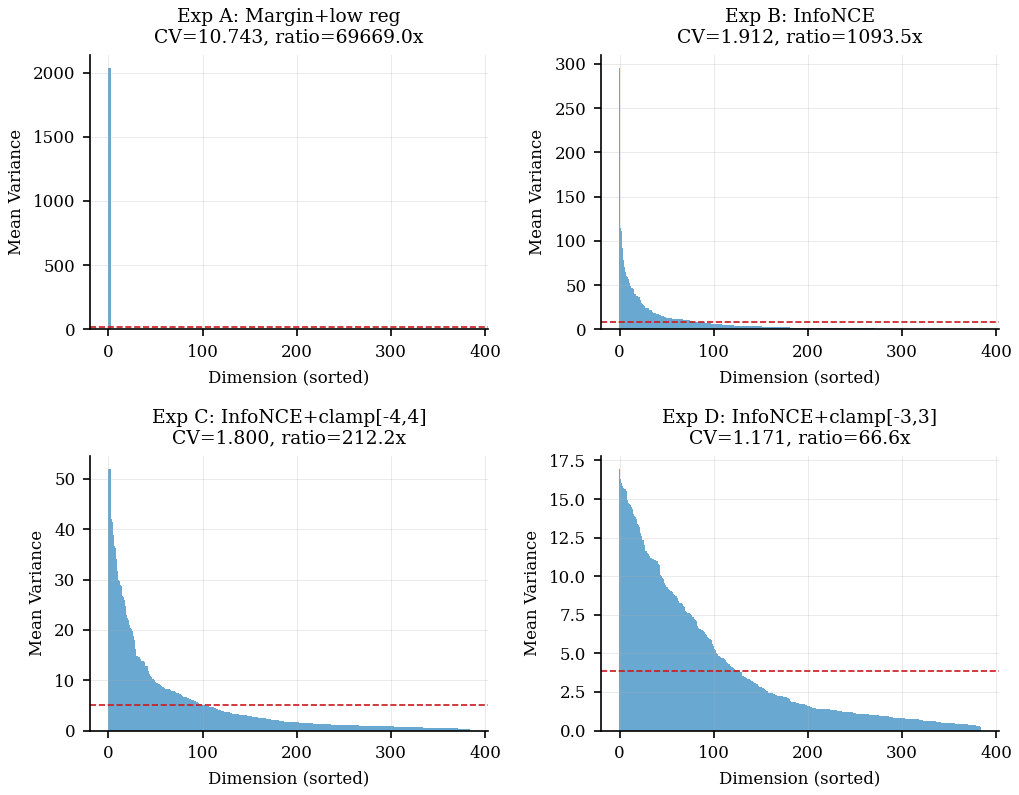

📊 已保存: ablation_variance_comparison.pdf / .png


In [ ]:
# ====== 退化检验：对比四组实验的方差分布 ======

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.5))
axes = axes.flatten()

exp_models = [
    ('Exp A: Margin+low reg', model_A),
    ('Exp B: InfoNCE', model_B),
    ('Exp C: InfoNCE+clamp[-4,4]', model_C),
    ('Exp D: InfoNCE+clamp[-3,3]', model_D),
]

for ax, (name, model) in zip(axes, exp_models):
    cv, ratio, all_vars = compute_cv(model, test_encoded)
    mean_v = np.mean(all_vars, axis=0)
    sorted_v = np.sort(mean_v)[::-1]

    ax.bar(range(len(sorted_v)), sorted_v, width=1.0, color='#4292C6', alpha=0.8, linewidth=0)
    ax.axhline(y=np.mean(mean_v), color='#CB181D', ls='--', lw=0.8)
    ax.set_title(f'{name}\nCV={cv:.3f}, ratio={ratio:.1f}x', fontsize=9)
    ax.set_xlabel('Dimension (sorted)', fontsize=8)
    ax.set_ylabel('Mean Variance', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ablation_variance_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('ablation_variance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('📊 已保存: ablation_variance_comparison.pdf / .png')

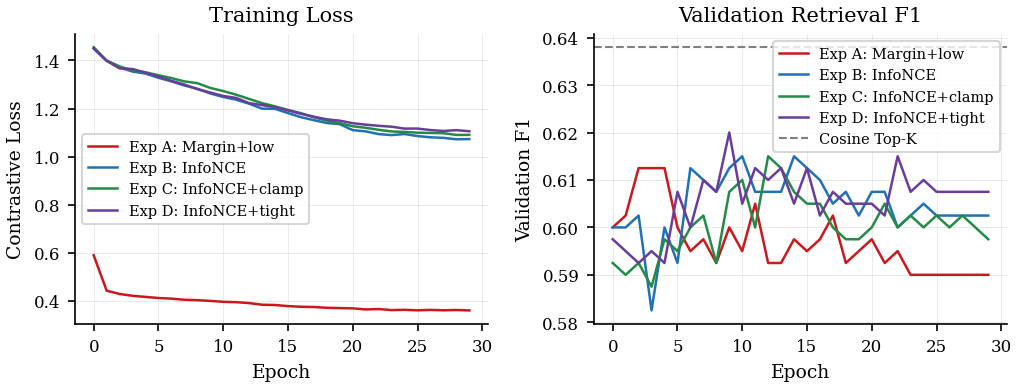

📊 已保存: ablation_training_curves.pdf / .png


In [ ]:
# ====== 训练曲线：验证集 F1 随训练进展的变化 ======

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))

colors = ['#CB181D', '#2171B5', '#238B45', '#6A3D9A']
labels_exp = ['Exp A: Margin+low', 'Exp B: InfoNCE', 'Exp C: InfoNCE+clamp', 'Exp D: InfoNCE+tight']
histories = [hist_A, hist_B, hist_C, hist_D]

# (a) 训练损失
for h, c, l in zip(histories, colors, labels_exp):
    axes[0].plot(h['contrastive'], color=c, label=l, lw=1.2)
axes[0].set_xlabel('Epoch', fontsize=9)
axes[0].set_ylabel('Contrastive Loss', fontsize=9)
axes[0].set_title('Training Loss', fontsize=10)
axes[0].legend(fontsize=7)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (b) 验证 F1
for h, c, l in zip(histories, colors, labels_exp):
    axes[1].plot(h['val_f1'], color=c, label=l, lw=1.2)
axes[1].axhline(y=baseline_cosine_f1, color='gray', ls='--', lw=1, label='Cosine Top-K')
axes[1].set_xlabel('Epoch', fontsize=9)
axes[1].set_ylabel('Validation F1', fontsize=9)
axes[1].set_title('Validation Retrieval F1', fontsize=10)
axes[1].legend(fontsize=7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ablation_training_curves.png', dpi=300, bbox_inches='tight')
plt.savefig('ablation_training_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('📊 已保存: ablation_training_curves.pdf / .png')

---
## 第5部分：选择差异分析

对比最佳各向异性模型与余弦 Top-K 选出的不同段落，
分析那些「F1判定为错但可能有用」的案例。

In [ ]:
# ====== 选择差异分析 ======

# 使用在消融实验中 F1 最高的模型
best_exp_name = max(
    [(n, r['f1']) for n, r in results_summary.items() if '第1A' not in n],
    key=lambda x: x[1]
)[0]
best_model = best_model_map.get(best_exp_name)
if best_model is None:
    # 如果找不到（名称不匹配），取实验C
    best_model = model_C
    best_exp_name = '实验C'

print(f'使用最优模型: {best_exp_name.replace(chr(10), " ")}')
print(f'F1: {results_summary[best_exp_name]["f1"]:.4f}')
print()

# 找出两种方法选择不同的案例
diff_cases = []
agree_cases = []

for i, s in enumerate(test_encoded):
    q, c = s['query_emb'], s['context_embs']
    labels = [ctx['is_supporting'] for ctx in test_data[i]['contexts']]

    cos_sel, _ = select_topk_cosine(q, c, k=2)
    ani_sel, _ = select_anisotropic(q, c, best_model, k=2)

    if set(cos_sel) != set(ani_sel):
        cos_correct = sum(1 for j in cos_sel if labels[j])
        ani_correct = sum(1 for j in ani_sel if labels[j])
        diff_cases.append({
            'idx': i,
            'question': test_data[i]['query'],
            'answer': test_data[i]['answer'],
            'cos_sel': list(cos_sel),
            'ani_sel': list(ani_sel),
            'cos_correct': cos_correct,
            'ani_correct': ani_correct,
            'labels': labels,
        })
    else:
        agree_cases.append(i)

print(f'选择一致的样本: {len(agree_cases)} ({100*len(agree_cases)/len(test_encoded):.1f}%)')
print(f'选择不同的样本: {len(diff_cases)} ({100*len(diff_cases)/len(test_encoded):.1f}%)')

# 分析不同案例中谁更对
ani_better = sum(1 for d in diff_cases if d['ani_correct'] > d['cos_correct'])
cos_better = sum(1 for d in diff_cases if d['cos_correct'] > d['ani_correct'])
same_correct = sum(1 for d in diff_cases if d['cos_correct'] == d['ani_correct'])

print(f'\n在选择不同的 {len(diff_cases)} 个案例中:')
print(f'  各向异性更优: {ani_better} ({100*ani_better/max(len(diff_cases),1):.1f}%)')
print(f'  余弦更优:     {cos_better} ({100*cos_better/max(len(diff_cases),1):.1f}%)')
print(f'  正确数相同:   {same_correct} ({100*same_correct/max(len(diff_cases),1):.1f}%)')

使用最优模型: 实验D (InfoNCE+紧截断)
F1: 0.6220

选择一致的样本: 364 (72.8%)
选择不同的样本: 136 (27.2%)

在选择不同的 136 个案例中:
  各向异性更优: 21 (15.4%)
  余弦更优:     37 (27.2%)
  正确数相同:   78 (57.4%)


In [ ]:
# ====== 展示具体案例 ======

# 展示各向异性更优的案例
print('\n' + '='*70)
print('各向异性更优的案例示例（前5个）')
print('='*70)

ani_wins = [d for d in diff_cases if d['ani_correct'] > d['cos_correct']]
for case in ani_wins[:5]:
    i = case['idx']
    print(f'\n--- 样本 {i} ---')
    print(f'问题: {case["question"]}')
    print(f'答案: {case["answer"]}')
    print(f'余弦选择 (命中{case["cos_correct"]}/2):', [test_data[i]['contexts'][j]['title'] for j in case['cos_sel']])
    print(f'各向异性选择 (命中{case["ani_correct"]}/2):', [test_data[i]['contexts'][j]['title'] for j in case['ani_sel']])

# 展示余弦更优的案例
print('\n' + '='*70)
print('余弦更优的案例示例（前5个）')
print('='*70)

cos_wins = [d for d in diff_cases if d['cos_correct'] > d['ani_correct']]
for case in cos_wins[:5]:
    i = case['idx']
    print(f'\n--- 样本 {i} ---')
    print(f'问题: {case["question"]}')
    print(f'答案: {case["answer"]}')
    print(f'余弦选择 (命中{case["cos_correct"]}/2):', [test_data[i]['contexts'][j]['title'] for j in case['cos_sel']])
    print(f'各向异性选择 (命中{case["ani_correct"]}/2):', [test_data[i]['contexts'][j]['title'] for j in case['ani_sel']])


各向异性更优的案例示例（前5个）

--- 样本 8 ---
问题: Which genus of plant grows originally in Mexico and Guatemala, Phylica or Weldenia?
答案: Weldenia
余弦选择 (命中1/2): ['Weldenia', 'Mendoncia velloziana']
各向异性选择 (命中2/2): ['Weldenia', 'Phylica']

--- 样本 11 ---
问题: Kurt Cobain: Montage of Heck documents the life of Cobain until his suicide in what state?
答案: Washington
余弦选择 (命中1/2): ['Kurt Cobain: Montage of Heck', 'Montage of Heck: The Home Recordings']
各向异性选择 (命中2/2): ['Kurt Cobain: Montage of Heck', 'Suicide of Kurt Cobain']

--- 样本 50 ---
问题: Which band has been around longer Catfish and the Bottlemen or The Lumineers?
答案: The Lumineers
余弦选择 (命中1/2): ['Catfish and the Bottlemen', 'The Ride (Catfish and the Bottlemen album)']
各向异性选择 (命中2/2): ['Catfish and the Bottlemen', 'The Lumineers']

--- 样本 76 ---
问题: Who starred in The Bronze and also showed up on the CBS sitcom "The Big Bang Theory"?
答案: Melissa Rauch
余弦选择 (命中0/2): ['Kevin Sussman', 'The Big Bang Theory (season 9)']
各向异性选择 (命中1/2): ['Kevin Sussman'

---
## 第6部分：最终总结与下一步

In [ ]:
# ====== 最终总结报告 ======

print('\n' + '#'*70)
print('#  第1B阶段消融实验总结报告')
print('#'*70)

print('\n## 1. 各实验 CV 与 F1 汇总')
for name, r in results_summary.items():
    delta = r['f1'] - cos_f1
    marker = '✅' if delta > 0 else '⚠️' if delta > -0.01 else '❌'
    print(f'  {marker} {name.replace(chr(10)," "):35s} F1={r["f1"]:.4f} (Δ={delta:+.4f}) CV={r["cv"]:.4f}')

print(f'\n  基线余弦 Top-K: F1={cos_f1:.4f}')

# 找最优
best = max(results_summary.items(), key=lambda x: x[1]['f1'])
best_delta = best[1]['f1'] - cos_f1

print(f'\n## 2. 最优模型: {best[0].replace(chr(10)," ")}')
print(f'  F1: {best[1]["f1"]:.4f} (vs 余弦 Δ={best_delta:+.4f})')
print(f'  CV: {best[1]["cv"]:.4f}')
print(f'  方差比: {best[1]["ratio"]:.1f}x')

print(f'\n## 3. 选择差异分析')
print(f'  选择不同: {len(diff_cases)}/{len(test_encoded)} ({100*len(diff_cases)/len(test_encoded):.1f}%)')
print(f'  各向异性更优: {ani_better}, 余弦更优: {cos_better}, 相同: {same_correct}')

print(f'\n## 4. 结论与下一步')
if best_delta > 0.005:
    print('  ✅ 消融实验成功！各向异性方法在优化后超越了余弦基线。')
    print('  核心发现: InfoNCE + 紧截断范围是关键改进。')
    print('  \n  建议下一步:')
    print('  1. 在最优配置上运行生成质量评估（ROUGE-L, BERTScore）')
    print('  2. 扩展到更强编码器（E5-large, 1024维）')
    print('  3. 在 NarrativeQA 和 NQ 上测试泛化性')
    print('  4. 撰写论文初稿')
elif best_delta > -0.005:
    print('  ⚡ 消融实验接近平局。各向异性方法与余弦基线持平。')
    print('  结合第1A阶段的生成质量提升（ROUGE-L +2.1%），')
    print('  仍然有论文价值——但需要更多证据。')
    print('  \n  建议下一步:')
    print('  1. 在最优配置上运行生成质量评估')
    print('  2. 尝试更强的编码器（当前的 MiniLM 可能太弱）')
    print('  3. 尝试更大的训练集（当前仅2000样本）')
    print('  4. 分析生成质量提升是否在新配置下保持')
else:
    print('  ❌ 消融实验未能超越基线。')
    print('  对角协方差可能不足以在此嵌入空间中提供优势。')
    print('  \n  建议下一步:')
    print('  1. 尝试低秩非对角协方差（d×r, r=10-30）')
    print('  2. 尝试基于注意力的软区域选择（而非高斯）')
    print('  3. 发表负面结果论文：分析为什么对角高斯不够')

print('\n' + '#'*70)


######################################################################
#  第1B阶段消融实验总结报告
######################################################################

## 1. 各实验 CV 与 F1 汇总
  ❌ 第1A阶段 (Margin+强正则)                  F1=0.6200 (Δ=-0.0180) CV=19.3500
  ❌ 实验A (Margin+弱正则)                    F1=0.6200 (Δ=-0.0180) CV=10.7430
  ❌ 实验B (InfoNCE)                       F1=0.6170 (Δ=-0.0210) CV=1.9120
  ❌ 实验C (InfoNCE+截断)                    F1=0.6190 (Δ=-0.0190) CV=1.8002
  ❌ 实验D (InfoNCE+紧截断)                   F1=0.6220 (Δ=-0.0160) CV=1.1710

  基线余弦 Top-K: F1=0.6380

## 2. 最优模型: 实验D (InfoNCE+紧截断)
  F1: 0.6220 (vs 余弦 Δ=-0.0160)
  CV: 1.1710
  方差比: 66.6x

## 3. 选择差异分析
  选择不同: 136/500 (27.2%)
  各向异性更优: 21, 余弦更优: 37, 相同: 78

## 4. 结论与下一步
  ❌ 消融实验未能超越基线。
  对角协方差可能不足以在此嵌入空间中提供优势。
  
  建议下一步:
  1. 尝试低秩非对角协方差（d×r, r=10-30）
  2. 尝试基于注意力的软区域选择（而非高斯）
  3. 发表负面结果论文：分析为什么对角高斯不够

######################################################################


In [ ]:
# ====== 保存最优模型检查点 ======

best_model_final = best_model_map.get(best[0], model_C)

checkpoint = {
    'model_state_dict': best_model_final.state_dict(),
    'embed_dim': EMBED_DIM,
    'experiment_name': best[0].replace('\n', ' '),
    'results_summary': results_summary,
    'baseline_cosine_f1': cos_f1,
    'best_f1': best[1]['f1'],
    'best_cv': best[1]['cv'],
    'diff_analysis': {
        'n_different': len(diff_cases),
        'ani_better': ani_better,
        'cos_better': cos_better,
    },
}

torch.save(checkpoint, 'phase1b_best_checkpoint.pt')
print('💾 最优模型检查点已保存: phase1b_best_checkpoint.pt')
print('   请上传到 Google Drive 以便后续使用。')

💾 最优模型检查点已保存: phase1b_best_checkpoint.pt
   请上传到 Google Drive 以便后续使用。
